# Evaluate Classification Results for HydraBLE Classification (Finetuning))

In [1]:
import os
from pathlib import Path

os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())

dataPathProcessed = str(Path.cwd()) + r"\data\csv" + r"\Processed Files\\"
logitsPath = str(Path.cwd()) + r"\out\modeling\logits_and_labels\\classification_finetuning\\"
plotPath = str(Path.cwd()) + r"\out\plots\modeling\classification_finetuning\\"
tablePath = str(Path.cwd()) + r"\out\tables\modeling\classification_finetuning\\"

Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


In [2]:
import pandas as pd
from data_processing.LabelLut import LABEL_OTHER_DEVICE
from evaluation_framework import Experiment, StaticMetricCollection, OSCRCurve, AccuracyOpenSet

pkt_df_test = pd.read_parquet(dataPathProcessed + r"classification_dataset_v2_test.parquet")

known_labels = sorted(list(pkt_df_test['Label'].unique()))
known_labels.remove(LABEL_OTHER_DEVICE)

label_lut = {i: label for i, label in enumerate(known_labels)}
label_id_unknown = len(label_lut)
label_lut[label_id_unknown] = LABEL_OTHER_DEVICE

PRECISION = 4
H_VALS = (1,2,4,8)

config = StaticMetricCollection([OSCRCurve(unknown_label=label_id_unknown, precision=PRECISION),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='macro'),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='micro'),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='binary')]
                                )

In [3]:
label_lut

{0: 'Apple Device',
 1: 'Apple Find My Device (offline)',
 2: 'Apple Find My Device (online)',
 3: 'Apple Find My Tracker (lost)',
 4: 'Apple Find My Tracker (nearby)',
 5: 'Apple Find My Tracker (unpaired)',
 6: 'Apple Find My Tracker Gen 2 (lost)',
 7: 'Apple Find My Tracker Gen 2 (nearby)',
 8: 'DULT (lost)',
 9: 'DULT (nearby)',
 10: 'Google Find My Tracker (lost)',
 11: 'Google Find My Tracker (unpaired)',
 12: 'Samsung SmartThings Tracker (lost)',
 13: 'Samsung SmartThings Tracker (nearby)',
 14: 'Tile Tracker (lost)',
 15: 'Other Device'}

In [4]:
import torch

thresholds = dict()
threshold_indexes = dict()
for h in H_VALS:
    logits = torch.load(logitsPath + f"logits_classification_h={h}_finetuning_validation.pt")
    targets  = torch.load(logitsPath + f"label_ids_classification_h={h}_finetuning_validation.pt")

    exp = Experiment(name="Test-Experiment")

    small_config =  StaticMetricCollection([AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='micro')])

    exp.configure(small_config)
    exp.add_data(logits=logits, targets=targets)

    score = exp.score()

    acc = score['Accuracy Open Set (micro)']
    threshold = acc.argmax() / len(acc)

    thresholds[h] = float(threshold)
    threshold_indexes[h] = int(acc.argmax())


Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.13 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.13 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.


In [5]:
print(thresholds)

{1: 0.4548545181751251, 2: 0.4329566955566406, 4: 0.3204679489135742, 8: 0.3828617036342621}


OSCR Curve started computing...
OSCR Curve finished computing in 0.02 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.15 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.14 minutes.


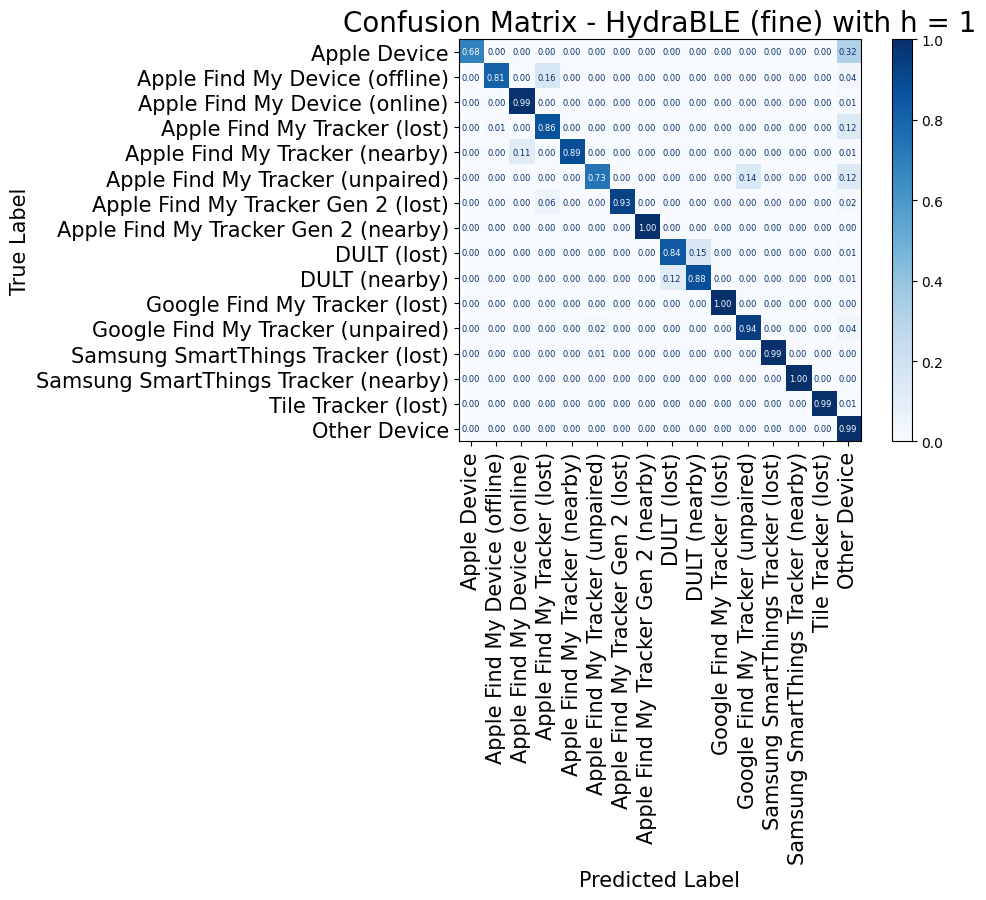

Classification Report - HydraBLE (fine) with h = 1
                                      precision    recall  f1-score   support

                        Apple Device     0.9927    0.6800    0.8071       200
      Apple Find My Device (offline)     0.9817    0.8050    0.8846       200
       Apple Find My Device (online)     0.9000    0.9900    0.9429       200
        Apple Find My Tracker (lost)     0.8009    0.8650    0.8317       200
      Apple Find My Tracker (nearby)     1.0000    0.8850    0.9390       200
    Apple Find My Tracker (unpaired)     0.9671    0.7350    0.8352       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    0.9250    0.9610       200
Apple Find My Tracker Gen 2 (nearby)     0.9950    1.0000    0.9975       200
                         DULT (lost)     0.8750    0.8400    0.8571       200
                       DULT (nearby)     0.8381    0.8800    0.8585       200
       Google Find My Tracker (lost)     1.0000    1.0000    1.0000       200
   Google Fi

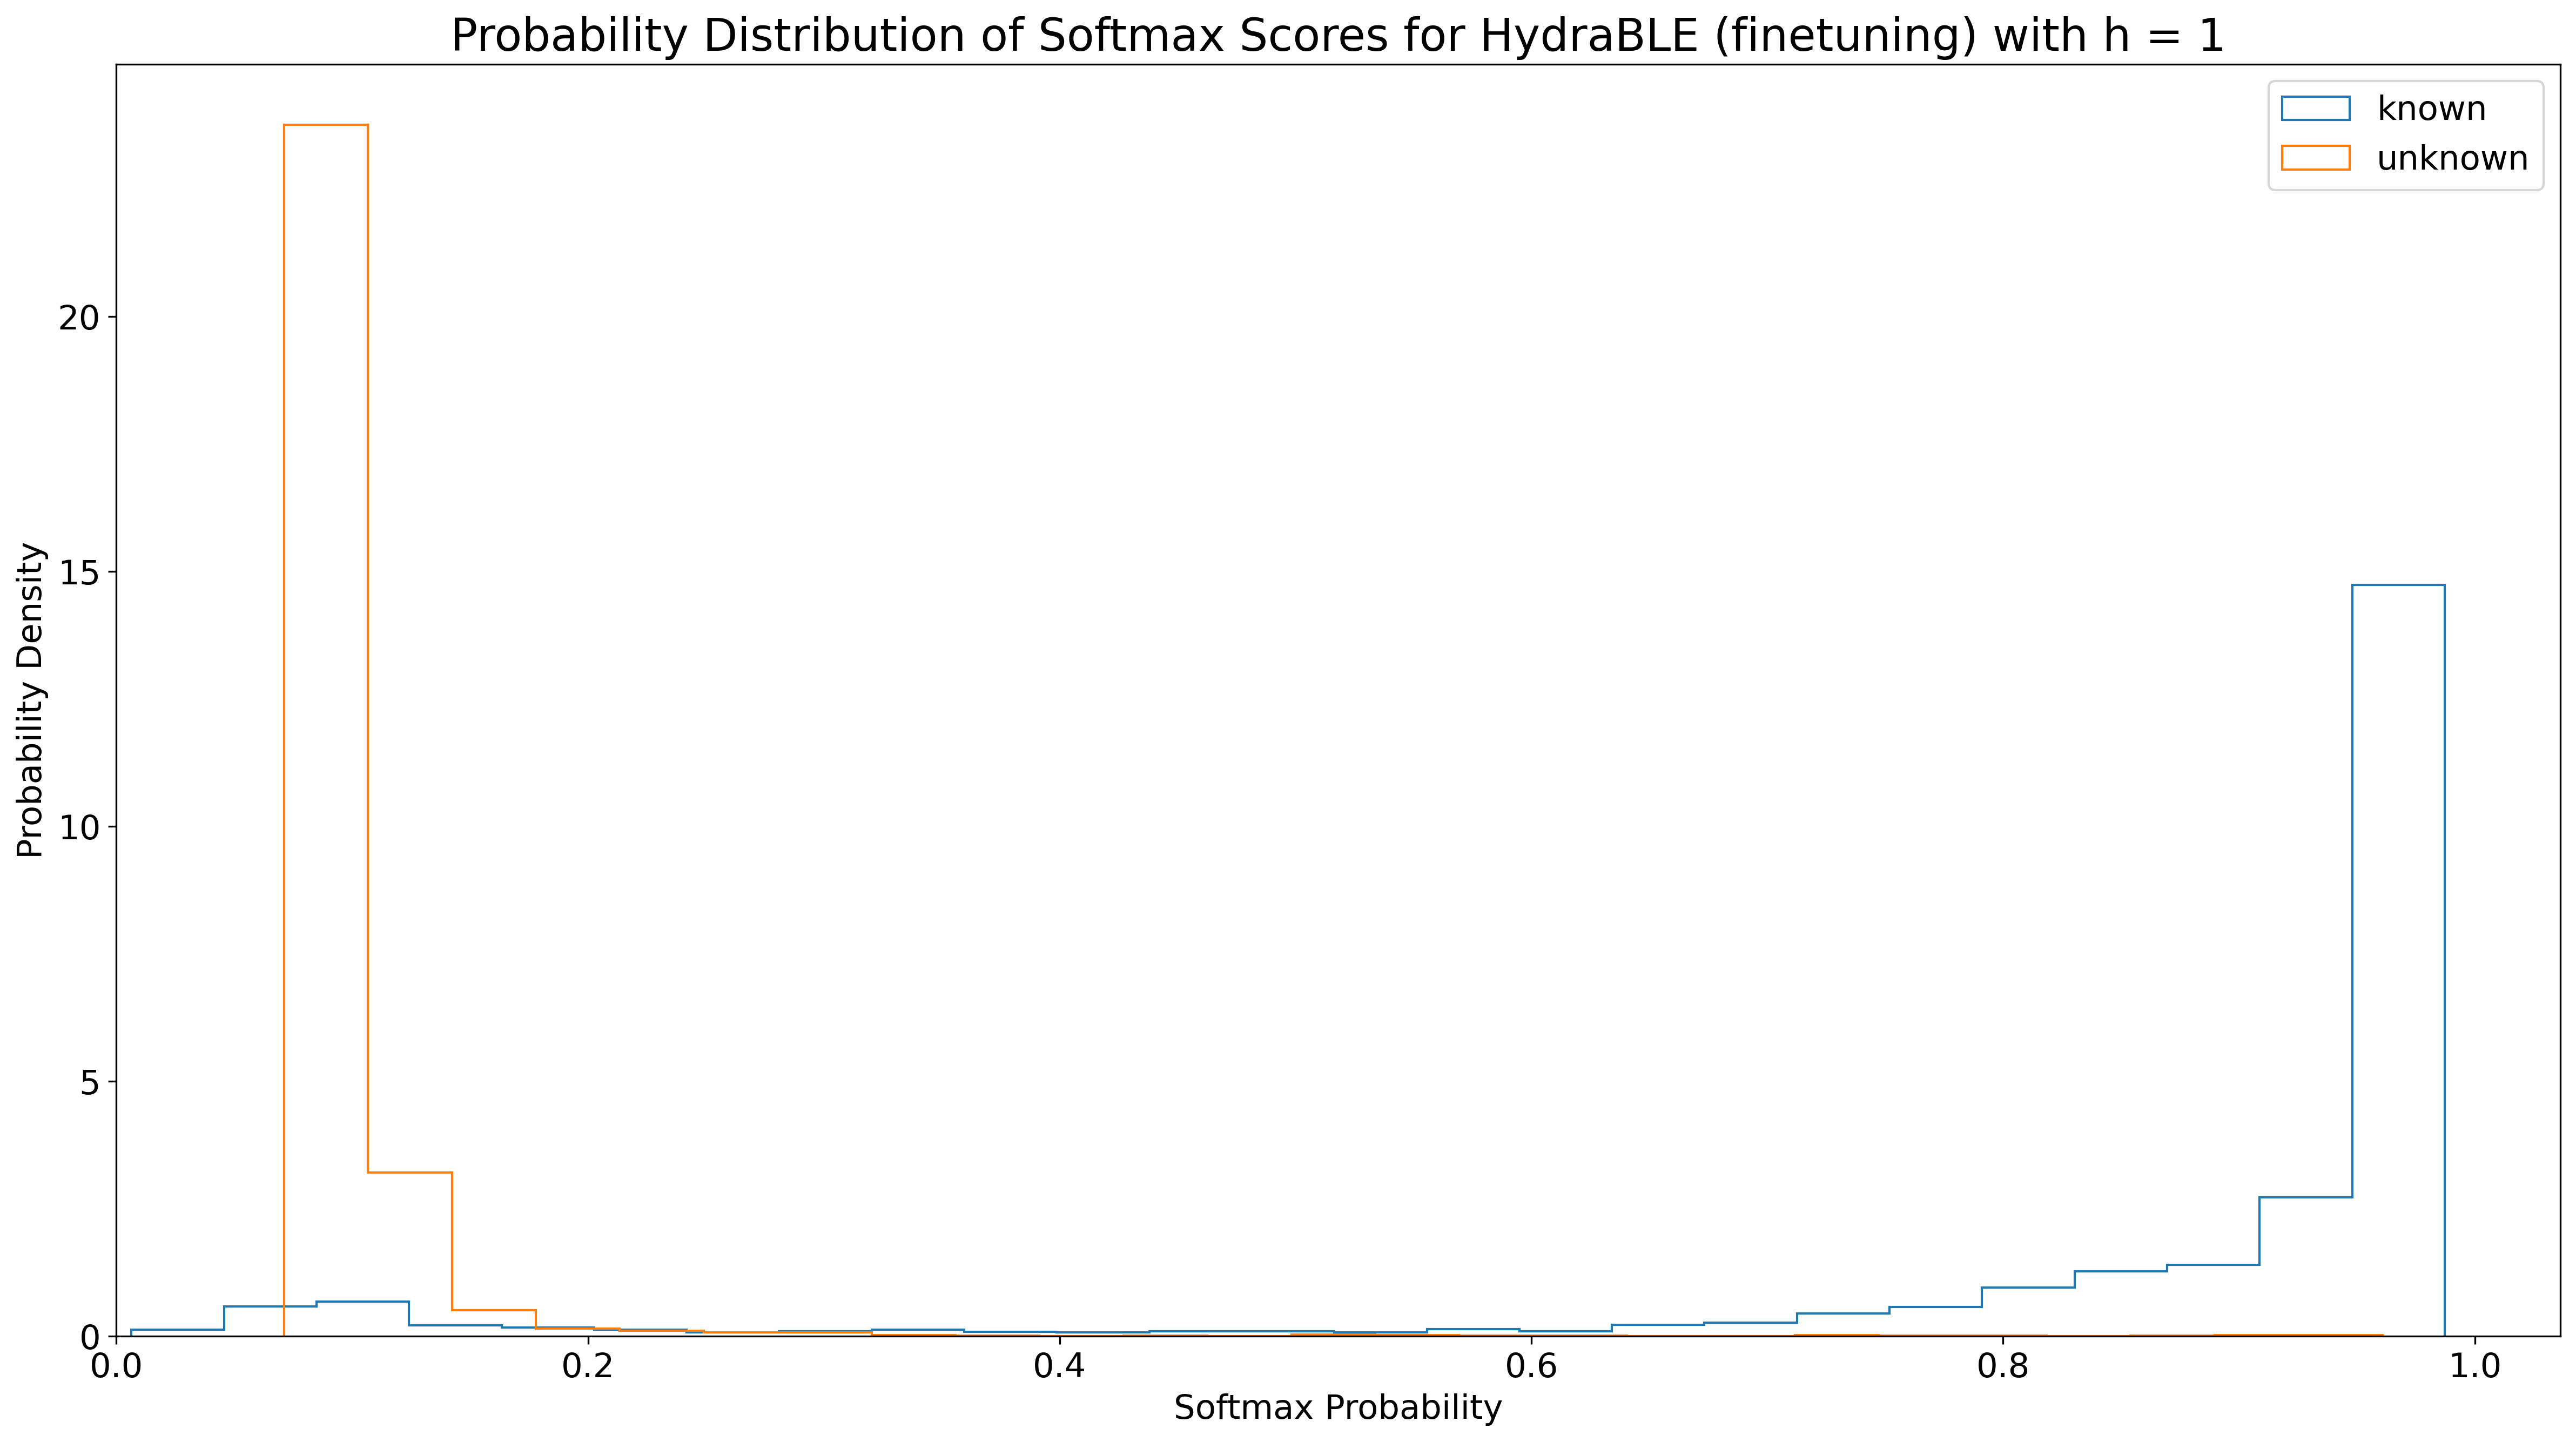

OSCR Curve started computing...
OSCR Curve finished computing in 0.04 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.14 minutes.


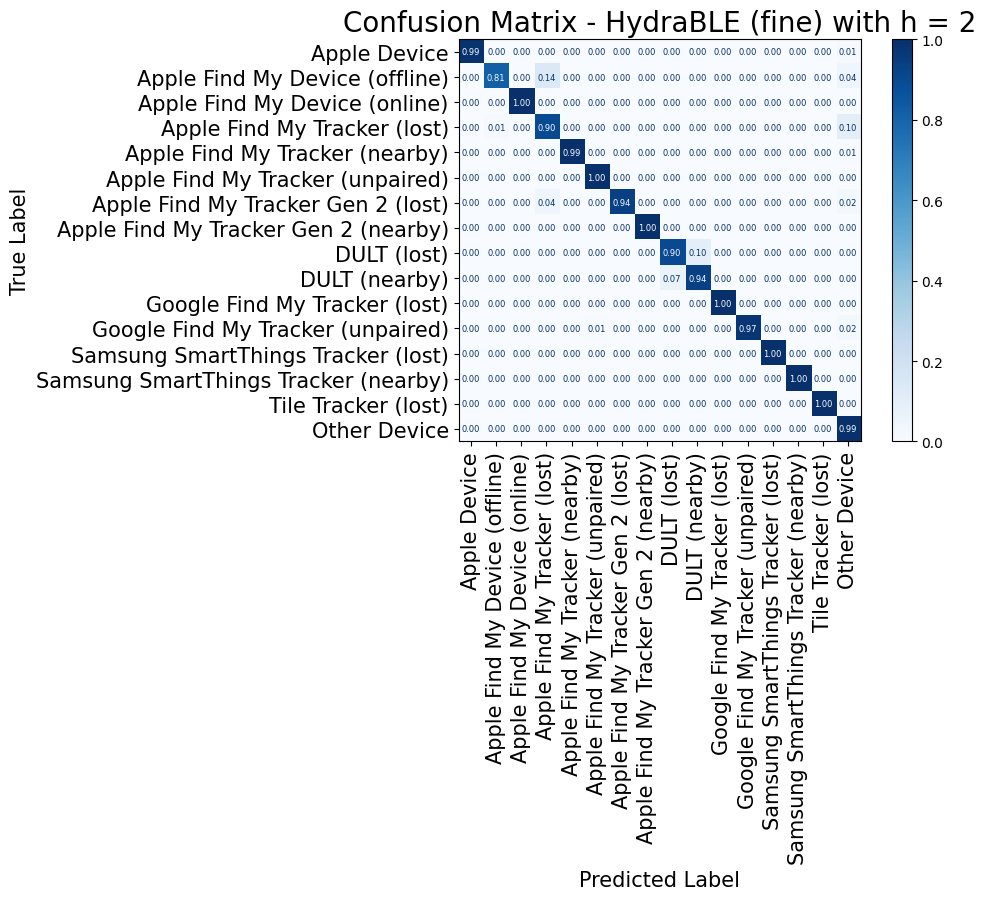

Classification Report - HydraBLE (fine) with h = 2
                                      precision    recall  f1-score   support

                        Apple Device     0.9802    0.9900    0.9851       200
      Apple Find My Device (offline)     0.9702    0.8150    0.8859       200
       Apple Find My Device (online)     0.9901    1.0000    0.9950       200
        Apple Find My Tracker (lost)     0.8211    0.8950    0.8565       200
      Apple Find My Tracker (nearby)     1.0000    0.9950    0.9975       200
    Apple Find My Tracker (unpaired)     0.9950    1.0000    0.9975       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    0.9350    0.9664       200
Apple Find My Tracker Gen 2 (nearby)     0.9950    1.0000    0.9975       200
                         DULT (lost)     0.9326    0.9000    0.9160       200
                       DULT (nearby)     0.8990    0.9350    0.9167       200
       Google Find My Tracker (lost)     1.0000    1.0000    1.0000       200
   Google Fi

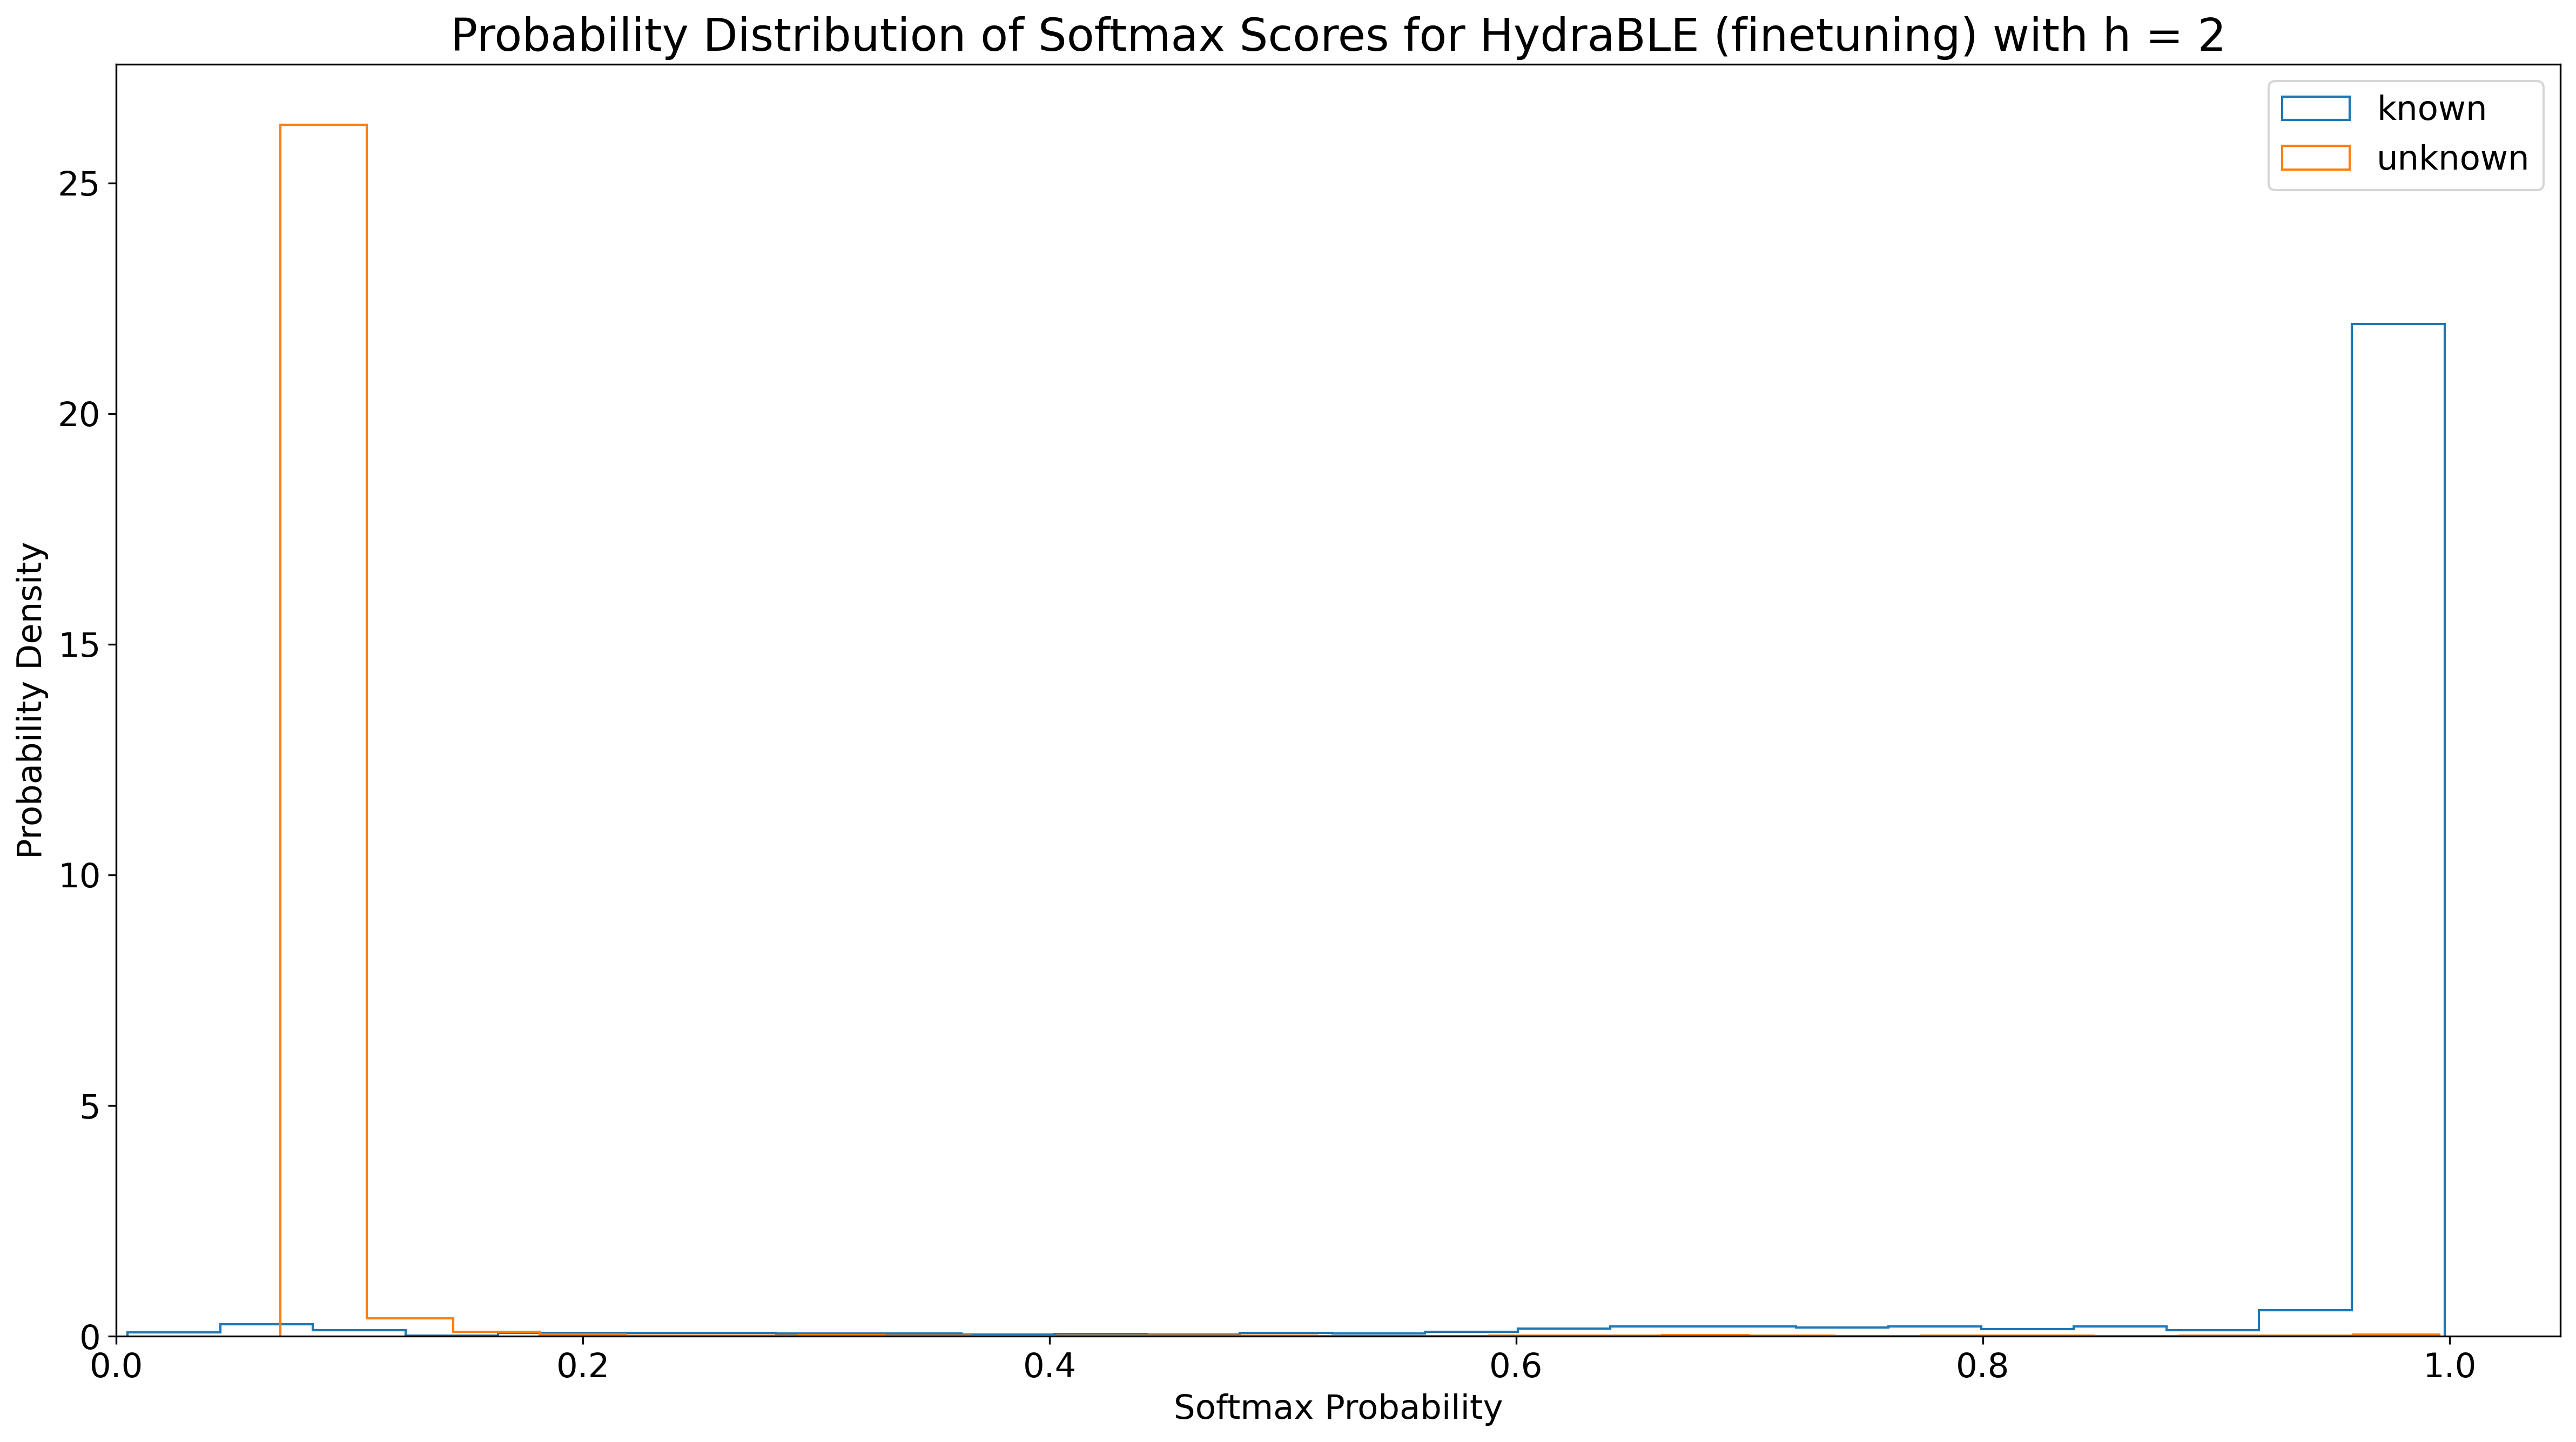

OSCR Curve started computing...
OSCR Curve finished computing in 0.04 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.14 minutes.


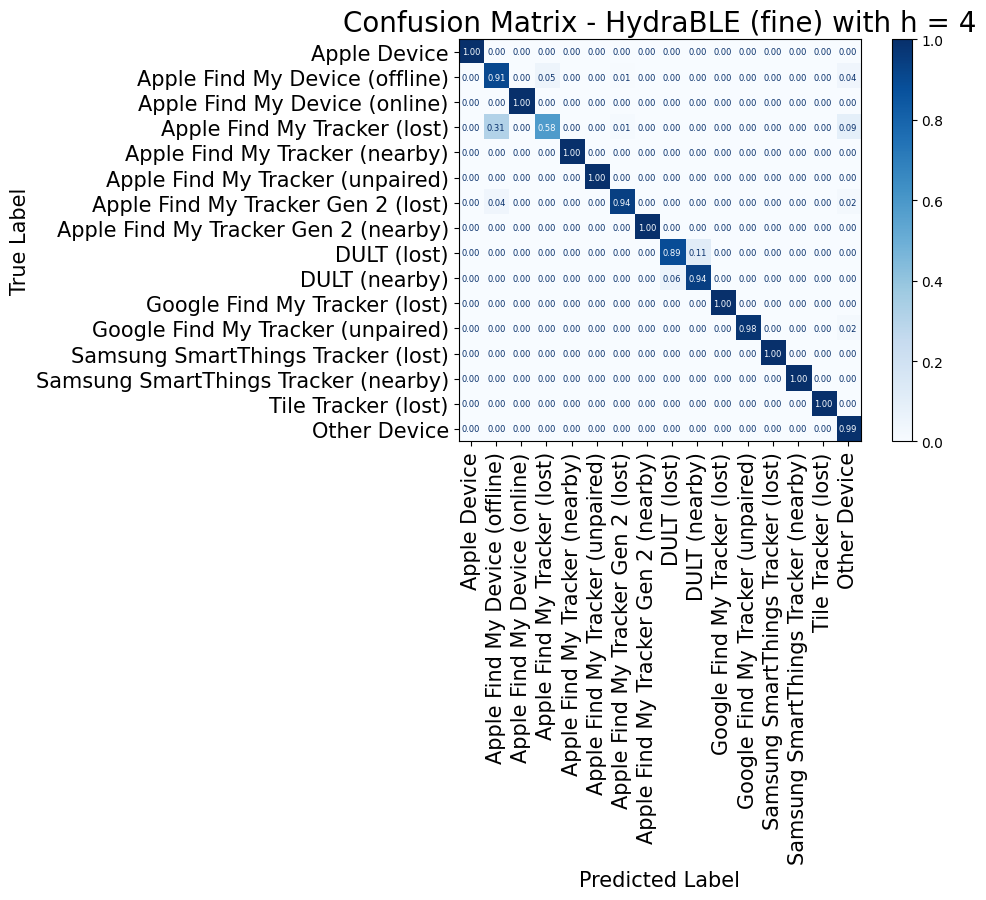

Classification Report - HydraBLE (fine) with h = 4
                                      precision    recall  f1-score   support

                        Apple Device     0.9524    1.0000    0.9756       200
      Apple Find My Device (offline)     0.7126    0.9050    0.7974       200
       Apple Find My Device (online)     0.9852    1.0000    0.9926       200
        Apple Find My Tracker (lost)     0.9070    0.5850    0.7112       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     1.0000    1.0000    1.0000       200
  Apple Find My Tracker Gen 2 (lost)     0.9792    0.9400    0.9592       200
Apple Find My Tracker Gen 2 (nearby)     1.0000    1.0000    1.0000       200
                         DULT (lost)     0.9319    0.8900    0.9105       200
                       DULT (nearby)     0.8952    0.9400    0.9171       200
       Google Find My Tracker (lost)     1.0000    1.0000    1.0000       200
   Google Fi

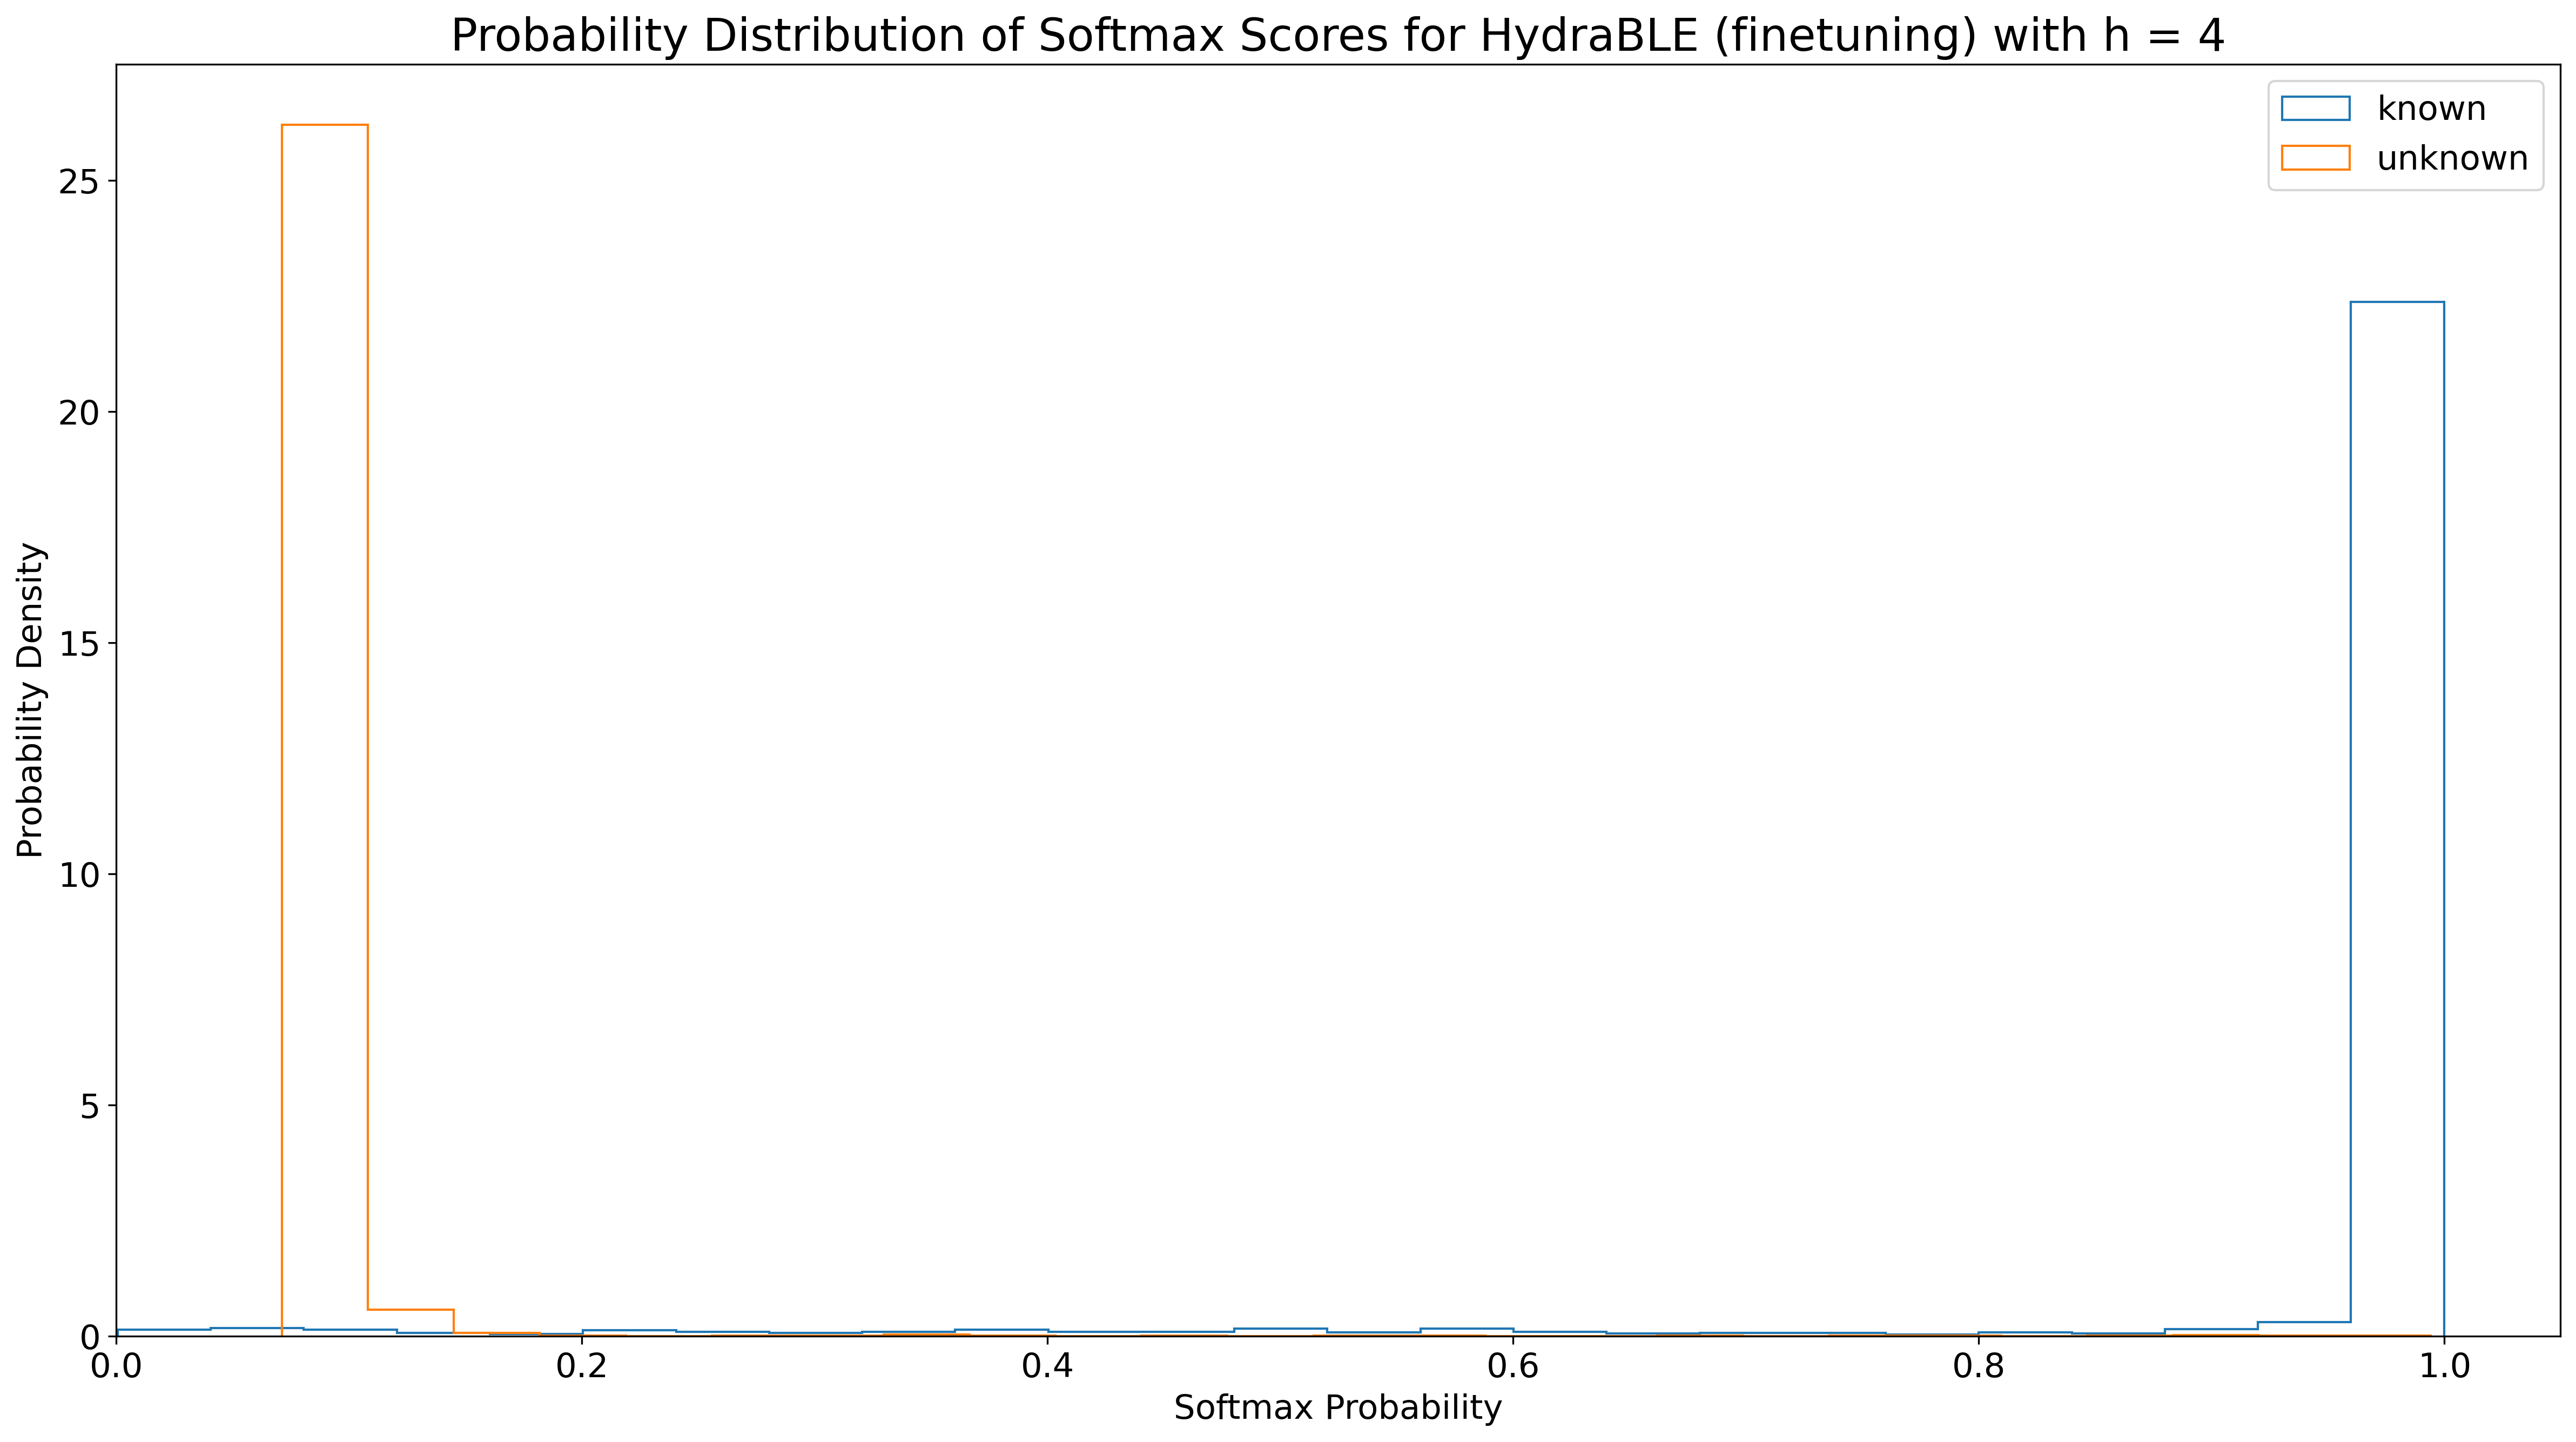

OSCR Curve started computing...
OSCR Curve finished computing in 0.04 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.14 minutes.


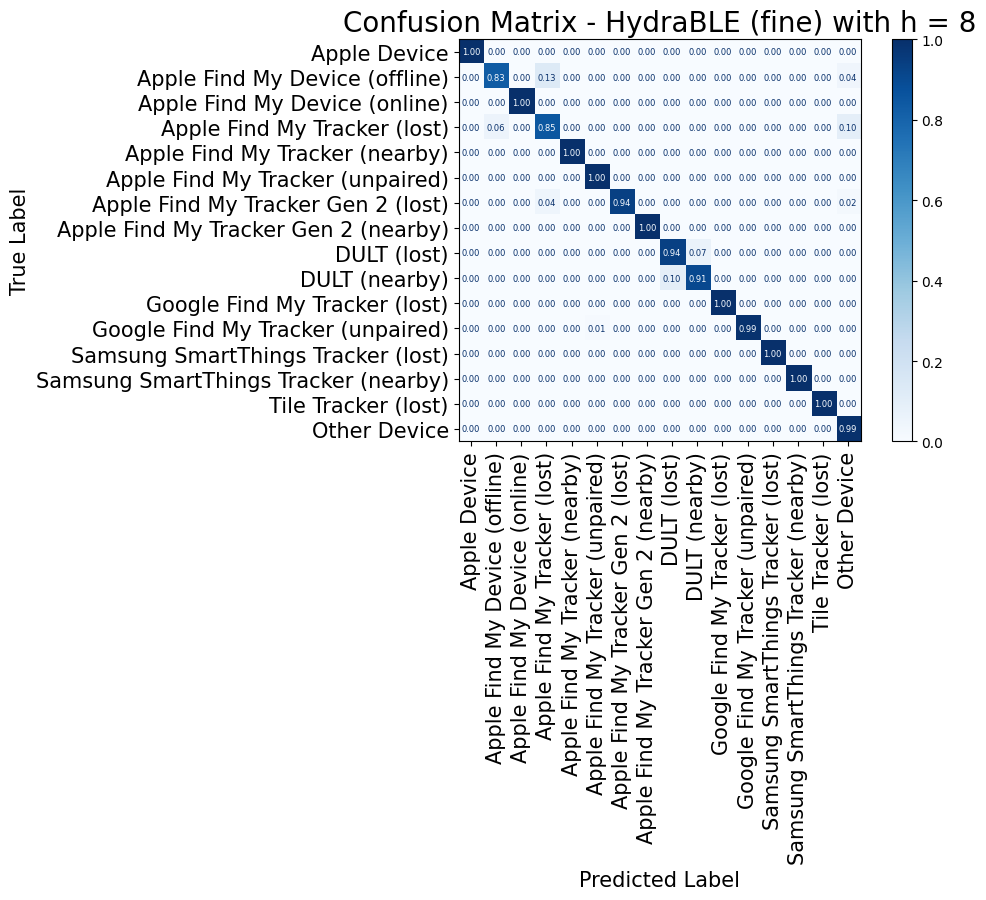

Classification Report - HydraBLE (fine) with h = 8
                                      precision    recall  f1-score   support

                        Apple Device     0.9662    1.0000    0.9828       200
      Apple Find My Device (offline)     0.9274    0.8300    0.8760       200
       Apple Find My Device (online)     1.0000    1.0000    1.0000       200
        Apple Find My Tracker (lost)     0.8213    0.8500    0.8354       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     0.9804    1.0000    0.9901       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    0.9350    0.9664       200
Apple Find My Tracker Gen 2 (nearby)     1.0000    1.0000    1.0000       200
                         DULT (lost)     0.9034    0.9350    0.9189       200
                       DULT (nearby)     0.9330    0.9050    0.9188       200
       Google Find My Tracker (lost)     1.0000    1.0000    1.0000       200
   Google Fi

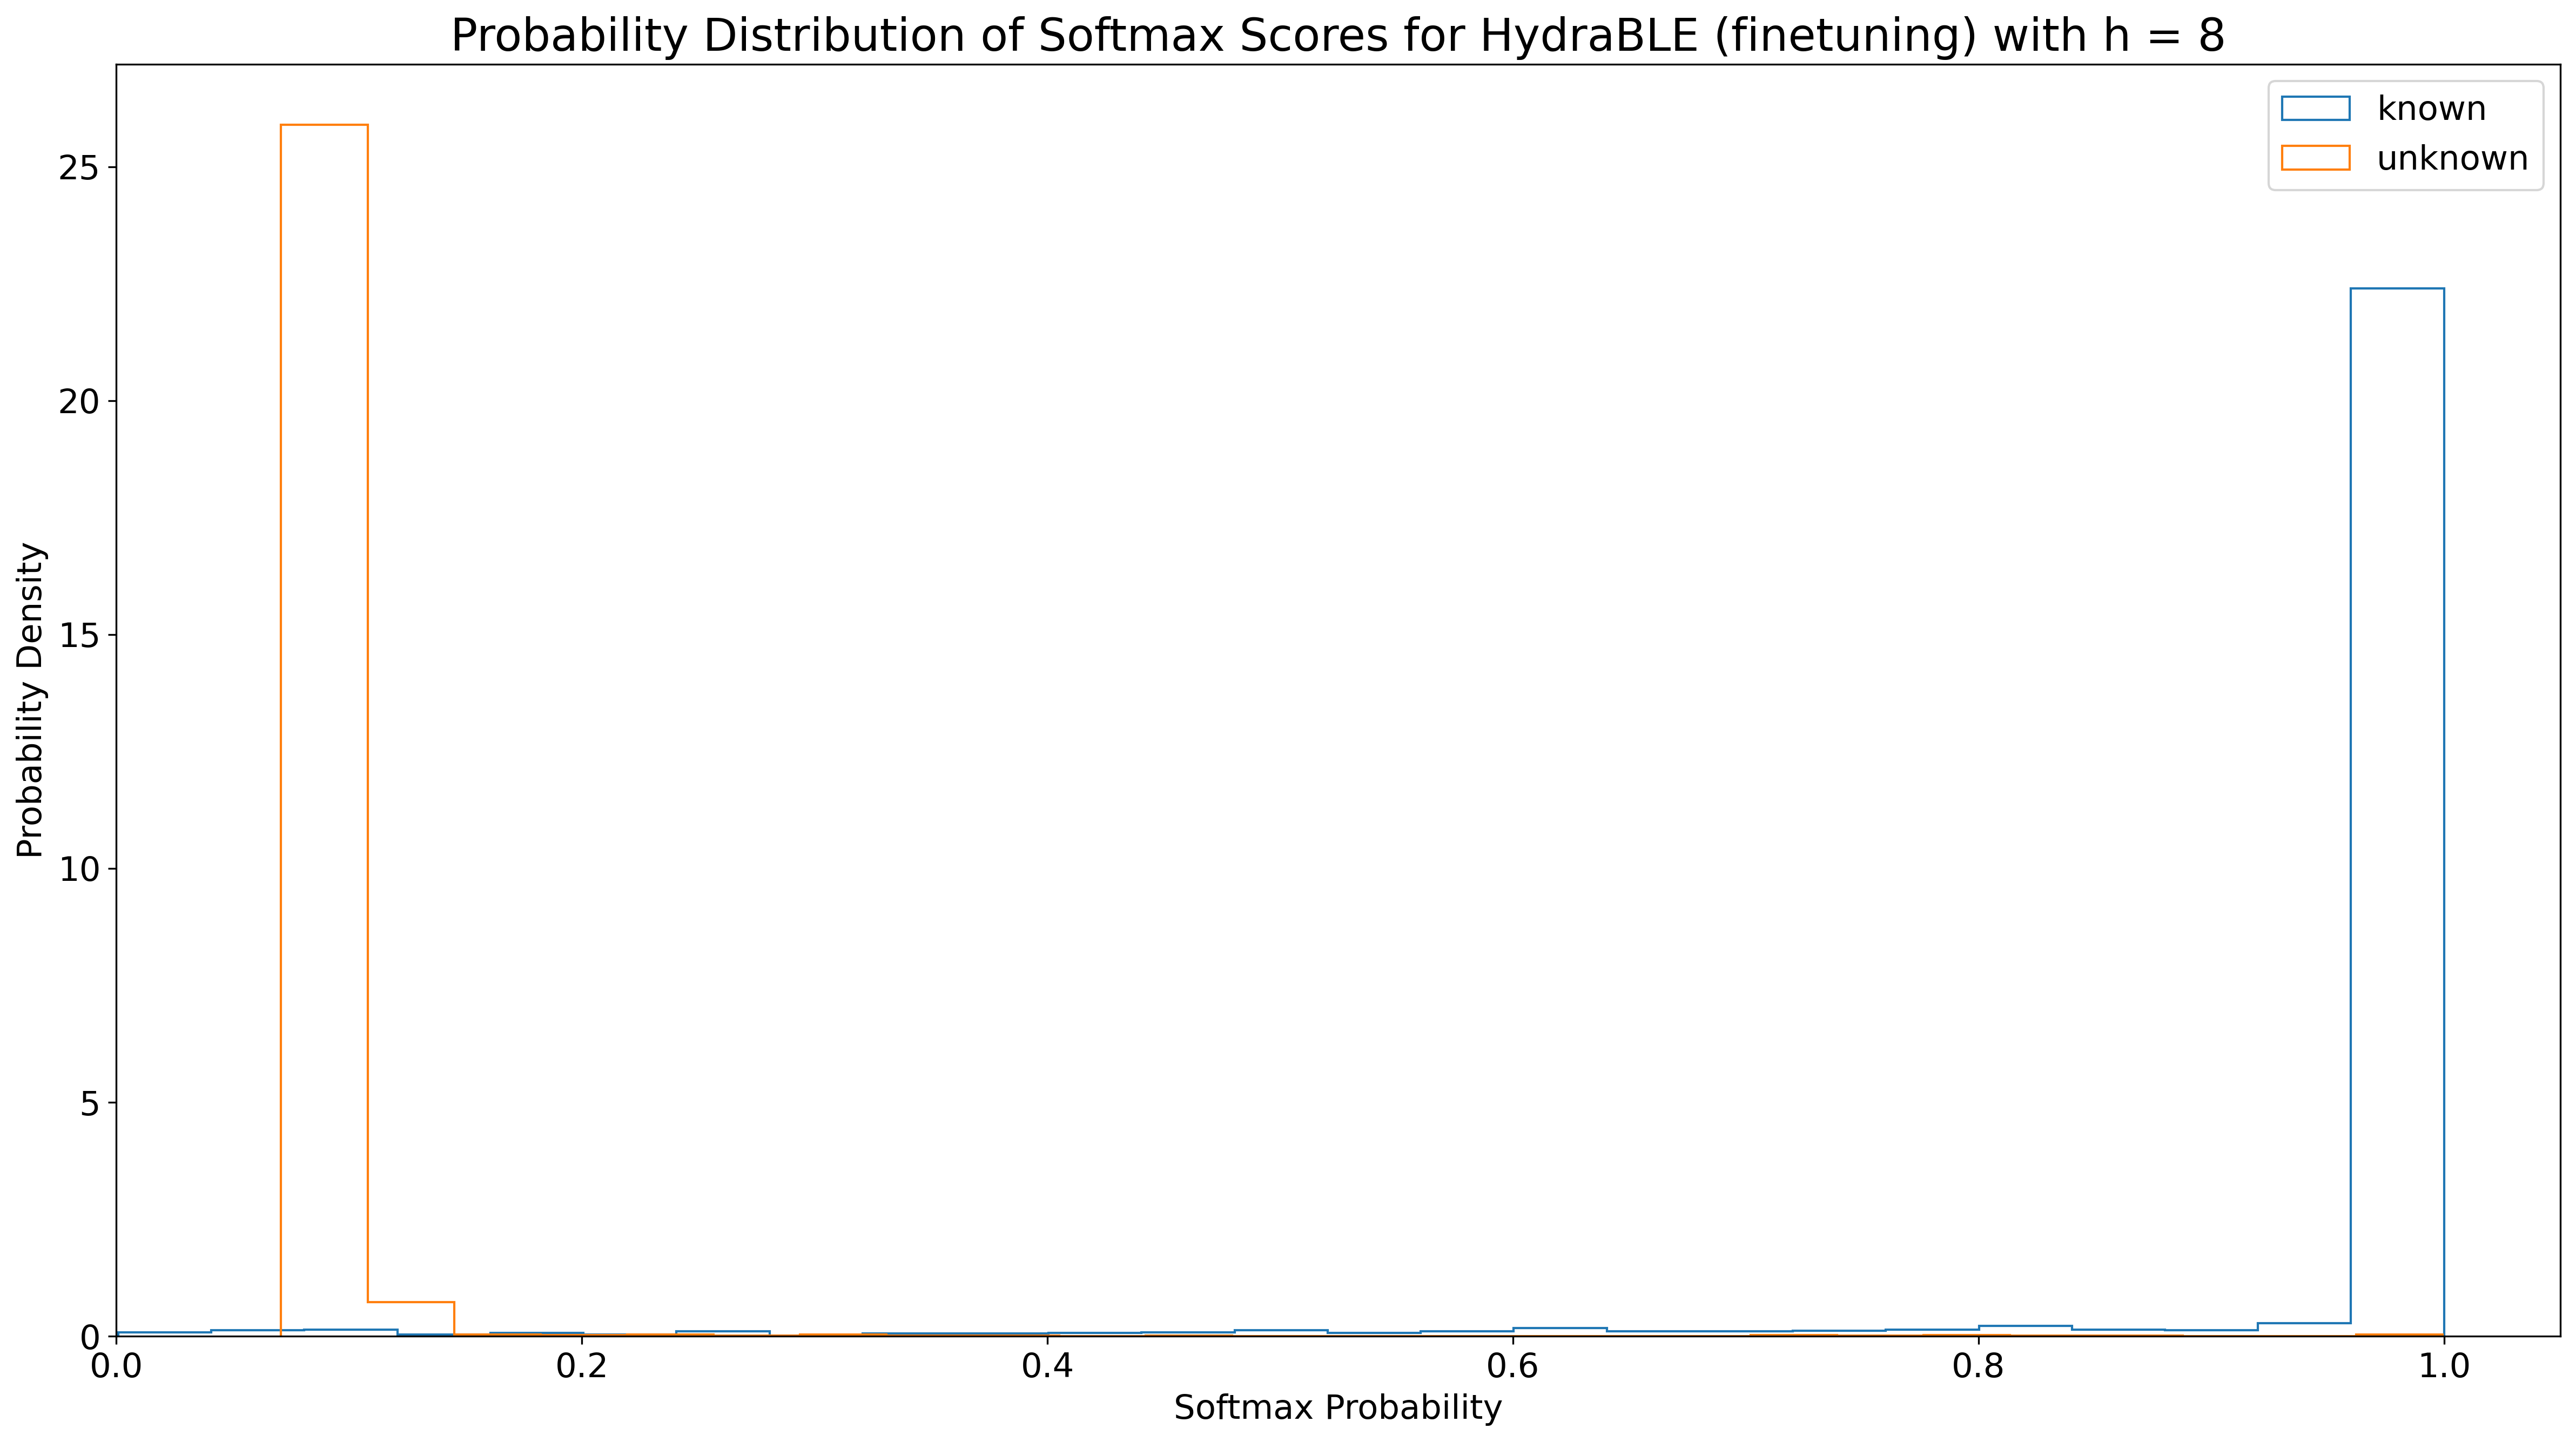

In [6]:
from plotting.src.functions import plotMatrix, FONTSIZE_LABEL, FONTSIZE_TICKS, FONTSIZE_TITLE, plotReport
import matplotlib.pyplot as plt
plt.style.use('default')

oscr_lut = dict()
acc_micro_lut = dict()
acc_macro_lut = dict()
acc_binary_lut = dict()

metric_table = [['Accuracy (micro)', 'Accuracy (macro)', 'Accuracy (binary)', 'CCR at FPR = 1e-1', 'CCR at FPR = 1e-2','CCR at FPR = 1e-3']]

for h in H_VALS:
    logits = torch.load(logitsPath + f"logits_classification_h={h}_finetuning_test.pt")
    targets  = torch.load(logitsPath + f"label_ids_classification_h={h}_finetuning_test.pt")

    exp = Experiment(name="Test-Experiment")
    exp.configure(config)
    exp.add_data(logits=logits, targets=targets)

    score = exp.score()

    threshold = thresholds[h]
    threshold_idx = threshold_indexes[h]

    probas = torch.nn.functional.softmax(logits, dim = 1)
    max_probas, pred_classes = probas.max(dim=1)

    predictions = torch.where(max_probas >= threshold, pred_classes, torch.full_like(pred_classes, label_id_unknown))

    predictions_text = [label_lut[int(i)] for i in predictions]
    targets_text = [label_lut[int(i)] for i in targets]

    plotMatrix(targets_text, predictions_text, list(label_lut.values()), name=f"HydraBLE (fine) with h = {h}", savePath=plotPath)
    plotReport(targets_text, predictions_text, list(label_lut.values()), name=f"HydraBLE (fine) with h = {h}", savePath=tablePath)

    oscr_lut[h] = score['OSCR Curve']
    acc_micro_lut[h] = score['Accuracy Open Set (micro)']
    acc_macro_lut[h] = score['Accuracy Open Set (macro)']
    acc_binary_lut[h] = score['Accuracy Open Set (binary)']


    fprs = oscr_lut[h][:, 0]
    ccrs = oscr_lut[h][:, 1]

    fpr_01_idx = torch.argmin(torch.abs(0.1 - fprs))
    fpr_001_idx = torch.argmin(torch.abs(0.01 - fprs))
    fpr_0001_idx = torch.argmin(torch.abs(0.001 - fprs))

    metric_table.append([float(acc_micro_lut[h][threshold_idx]),
                         float(acc_macro_lut[h][threshold_idx]),
                         float(acc_binary_lut[h][threshold_idx]),
                         float(ccrs[fpr_01_idx]),
                         float(ccrs[fpr_001_idx]),
                         float(ccrs[fpr_0001_idx])
                         ])


    probas = torch.nn.functional.softmax(logits, dim = 1)

    mask_known = (targets != label_id_unknown)
    mask_unknown = (targets == label_id_unknown)

    probas_known = probas[mask_known]
    probas_unknown = probas[mask_unknown]


    true_probas_known = probas_known[torch.arange(len(probas_known)), targets[mask_known]]
    max_probas_unknown, _ = probas_unknown.max(dim = 1)


    plt.figure(figsize=(16, 9), dpi = 300)
    plt.hist(true_probas_known, bins = 25, density=True, histtype='step', label='known')
    plt.hist(max_probas_unknown, bins = 25, density=True, histtype='step', label='unknown')

    plt.ylabel("Probability Density", fontsize=FONTSIZE_LABEL)
    plt.xlabel("Softmax Probability", fontsize=FONTSIZE_LABEL)

    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)

    plt.ylim(bottom = 0)
    plt.xlim(left=0)

    title = f"Probability Distribution of Softmax Scores for HydraBLE (finetuning) with h = {h}"
    plt.title(title, fontsize=FONTSIZE_TITLE)
    plt.legend(fontsize=FONTSIZE_LABEL)
    plt.tight_layout()

    plt.tight_layout()
    plt.savefig(plotPath + title + ".png", dpi = 300)
    plt.show()


In [7]:
import numpy as np

def plot_curve(lut: dict, title: str, y_label: str):
    plt.style.use('default')
    thresholds_x = np.linspace(0, 1, 10**PRECISION+1)

    plt.figure(figsize=(16, 9), dpi = 300)

    for h, values in lut.items():
        plt.plot(thresholds_x, values, label=f"h = {h}")

    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.xlabel("Threshold", fontsize=FONTSIZE_LABEL)
    plt.ylim(0, 1.1)
    plt.ylabel(y_label, fontsize=FONTSIZE_LABEL)
    plt.title(title, fontsize=FONTSIZE_TITLE)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plotPath + title + ".png", dpi = 300)
    plt.show()


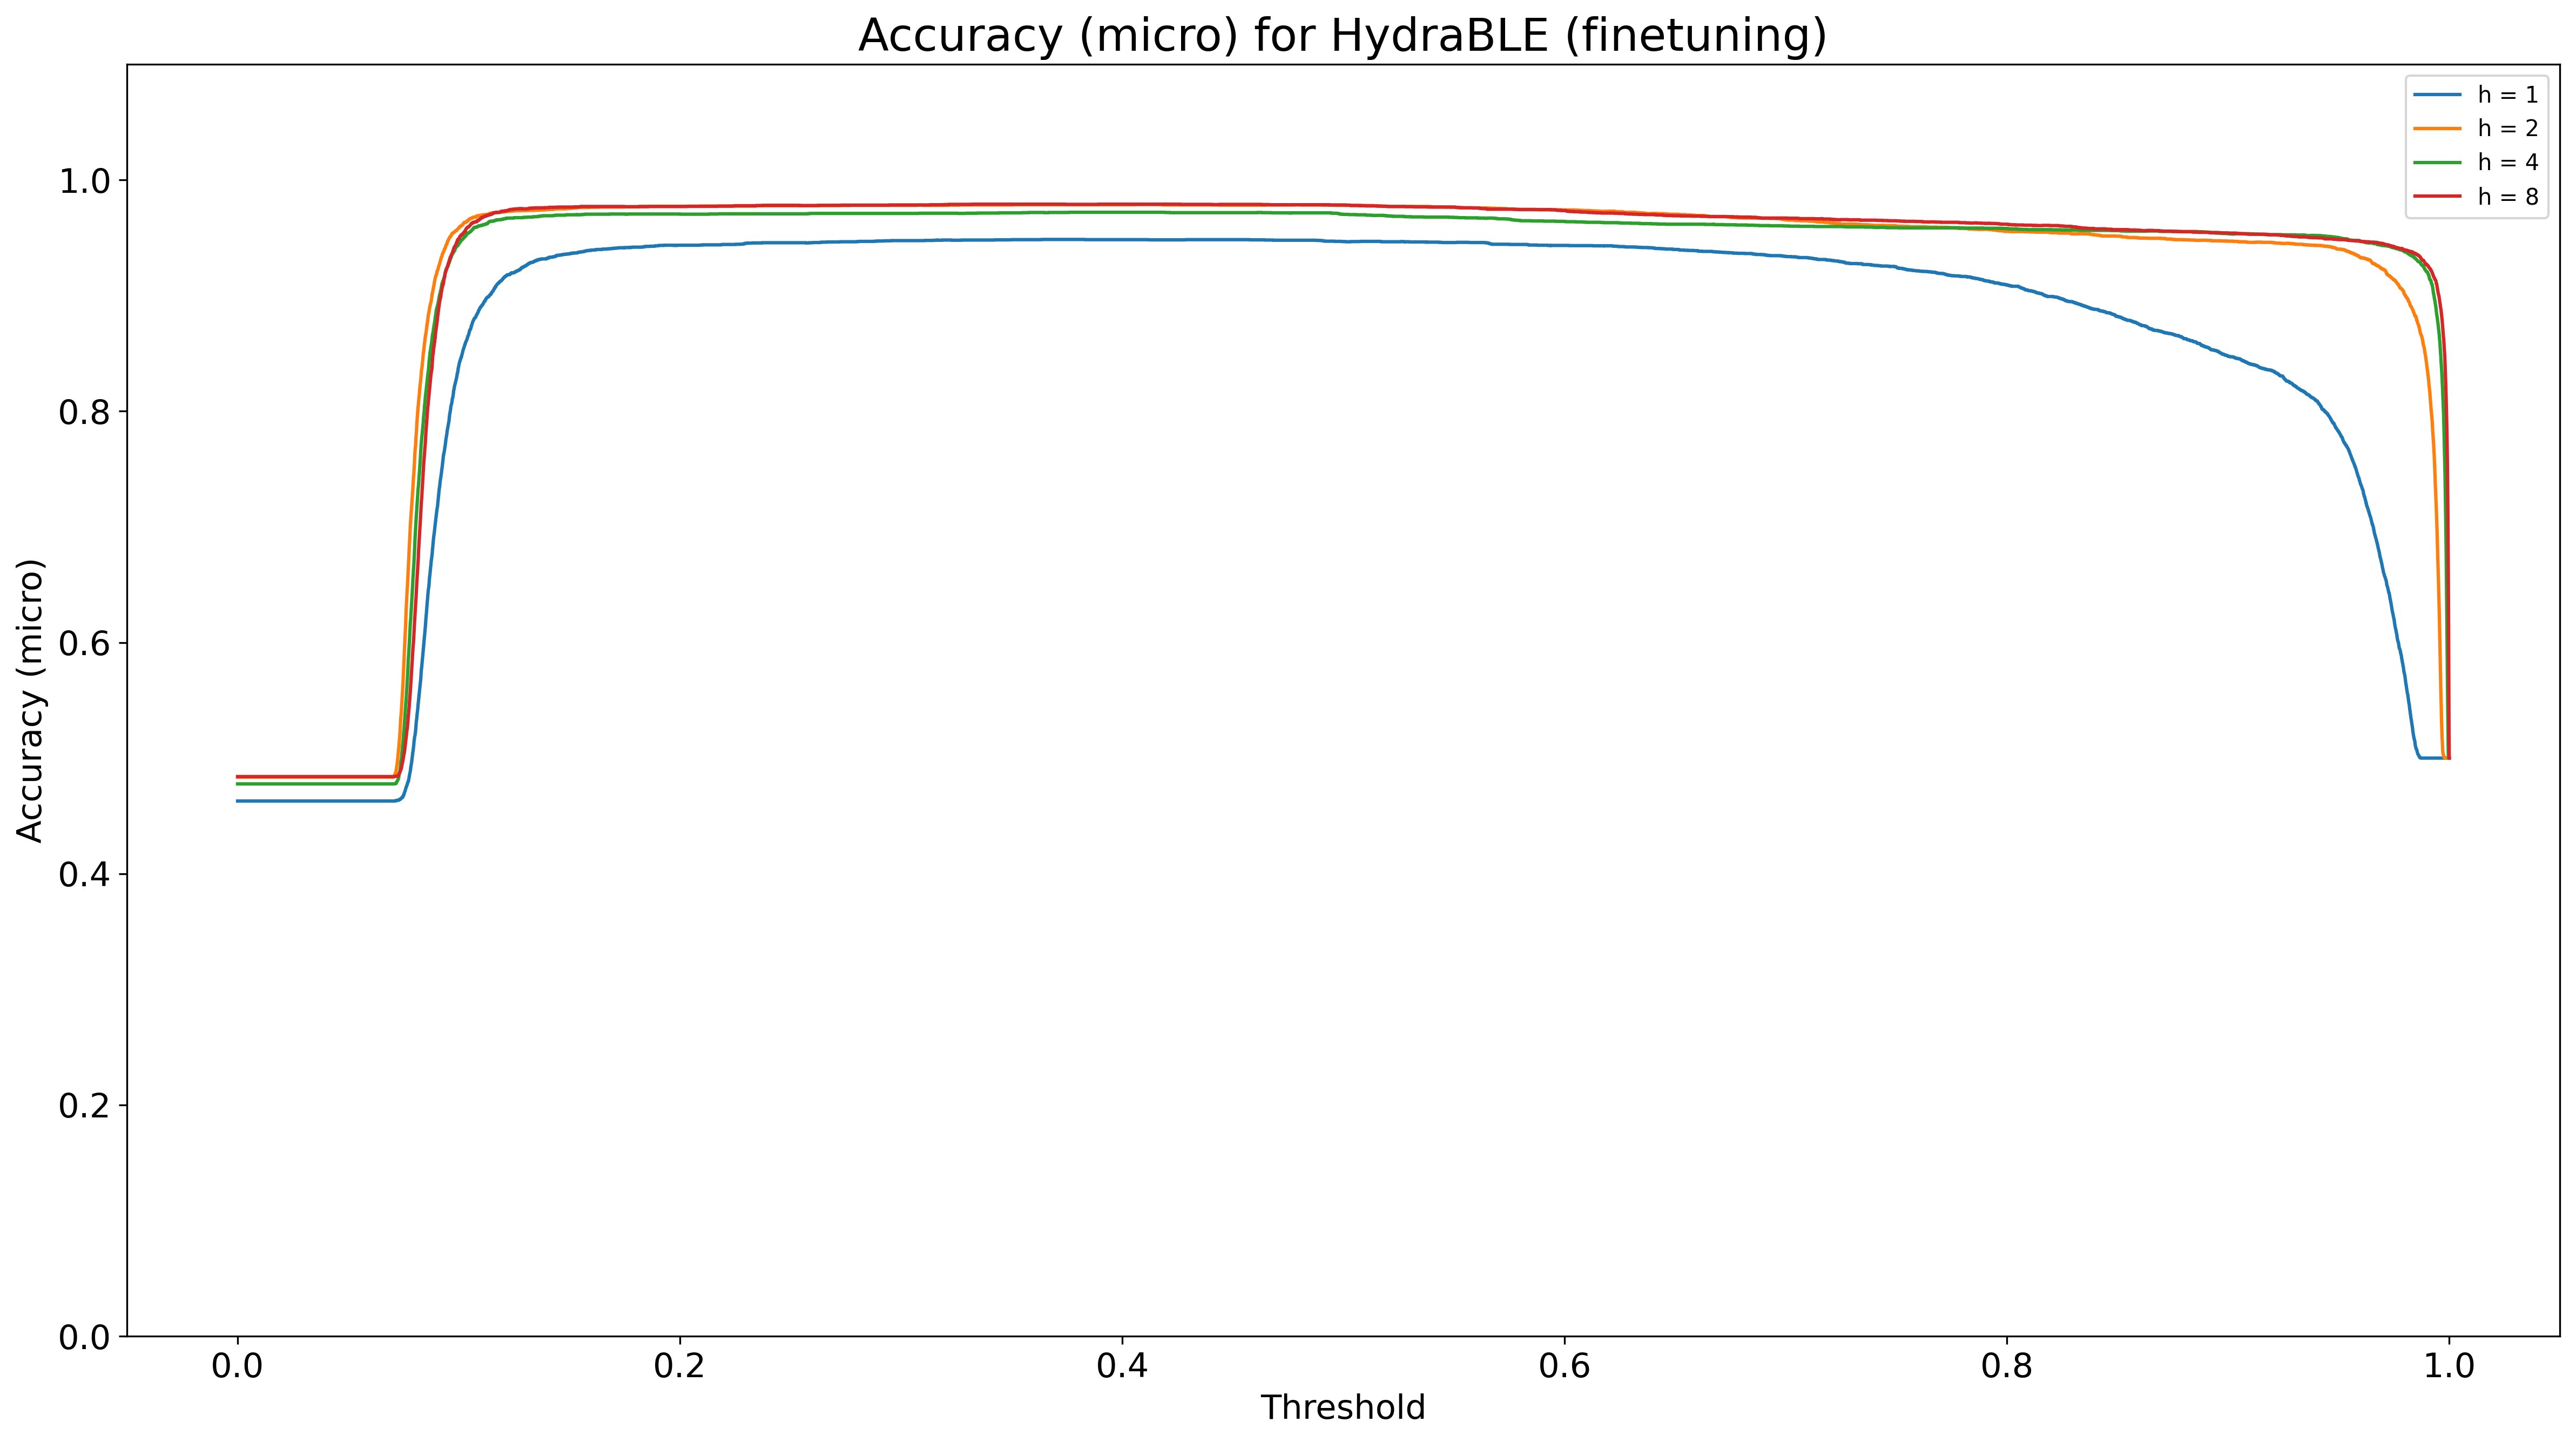

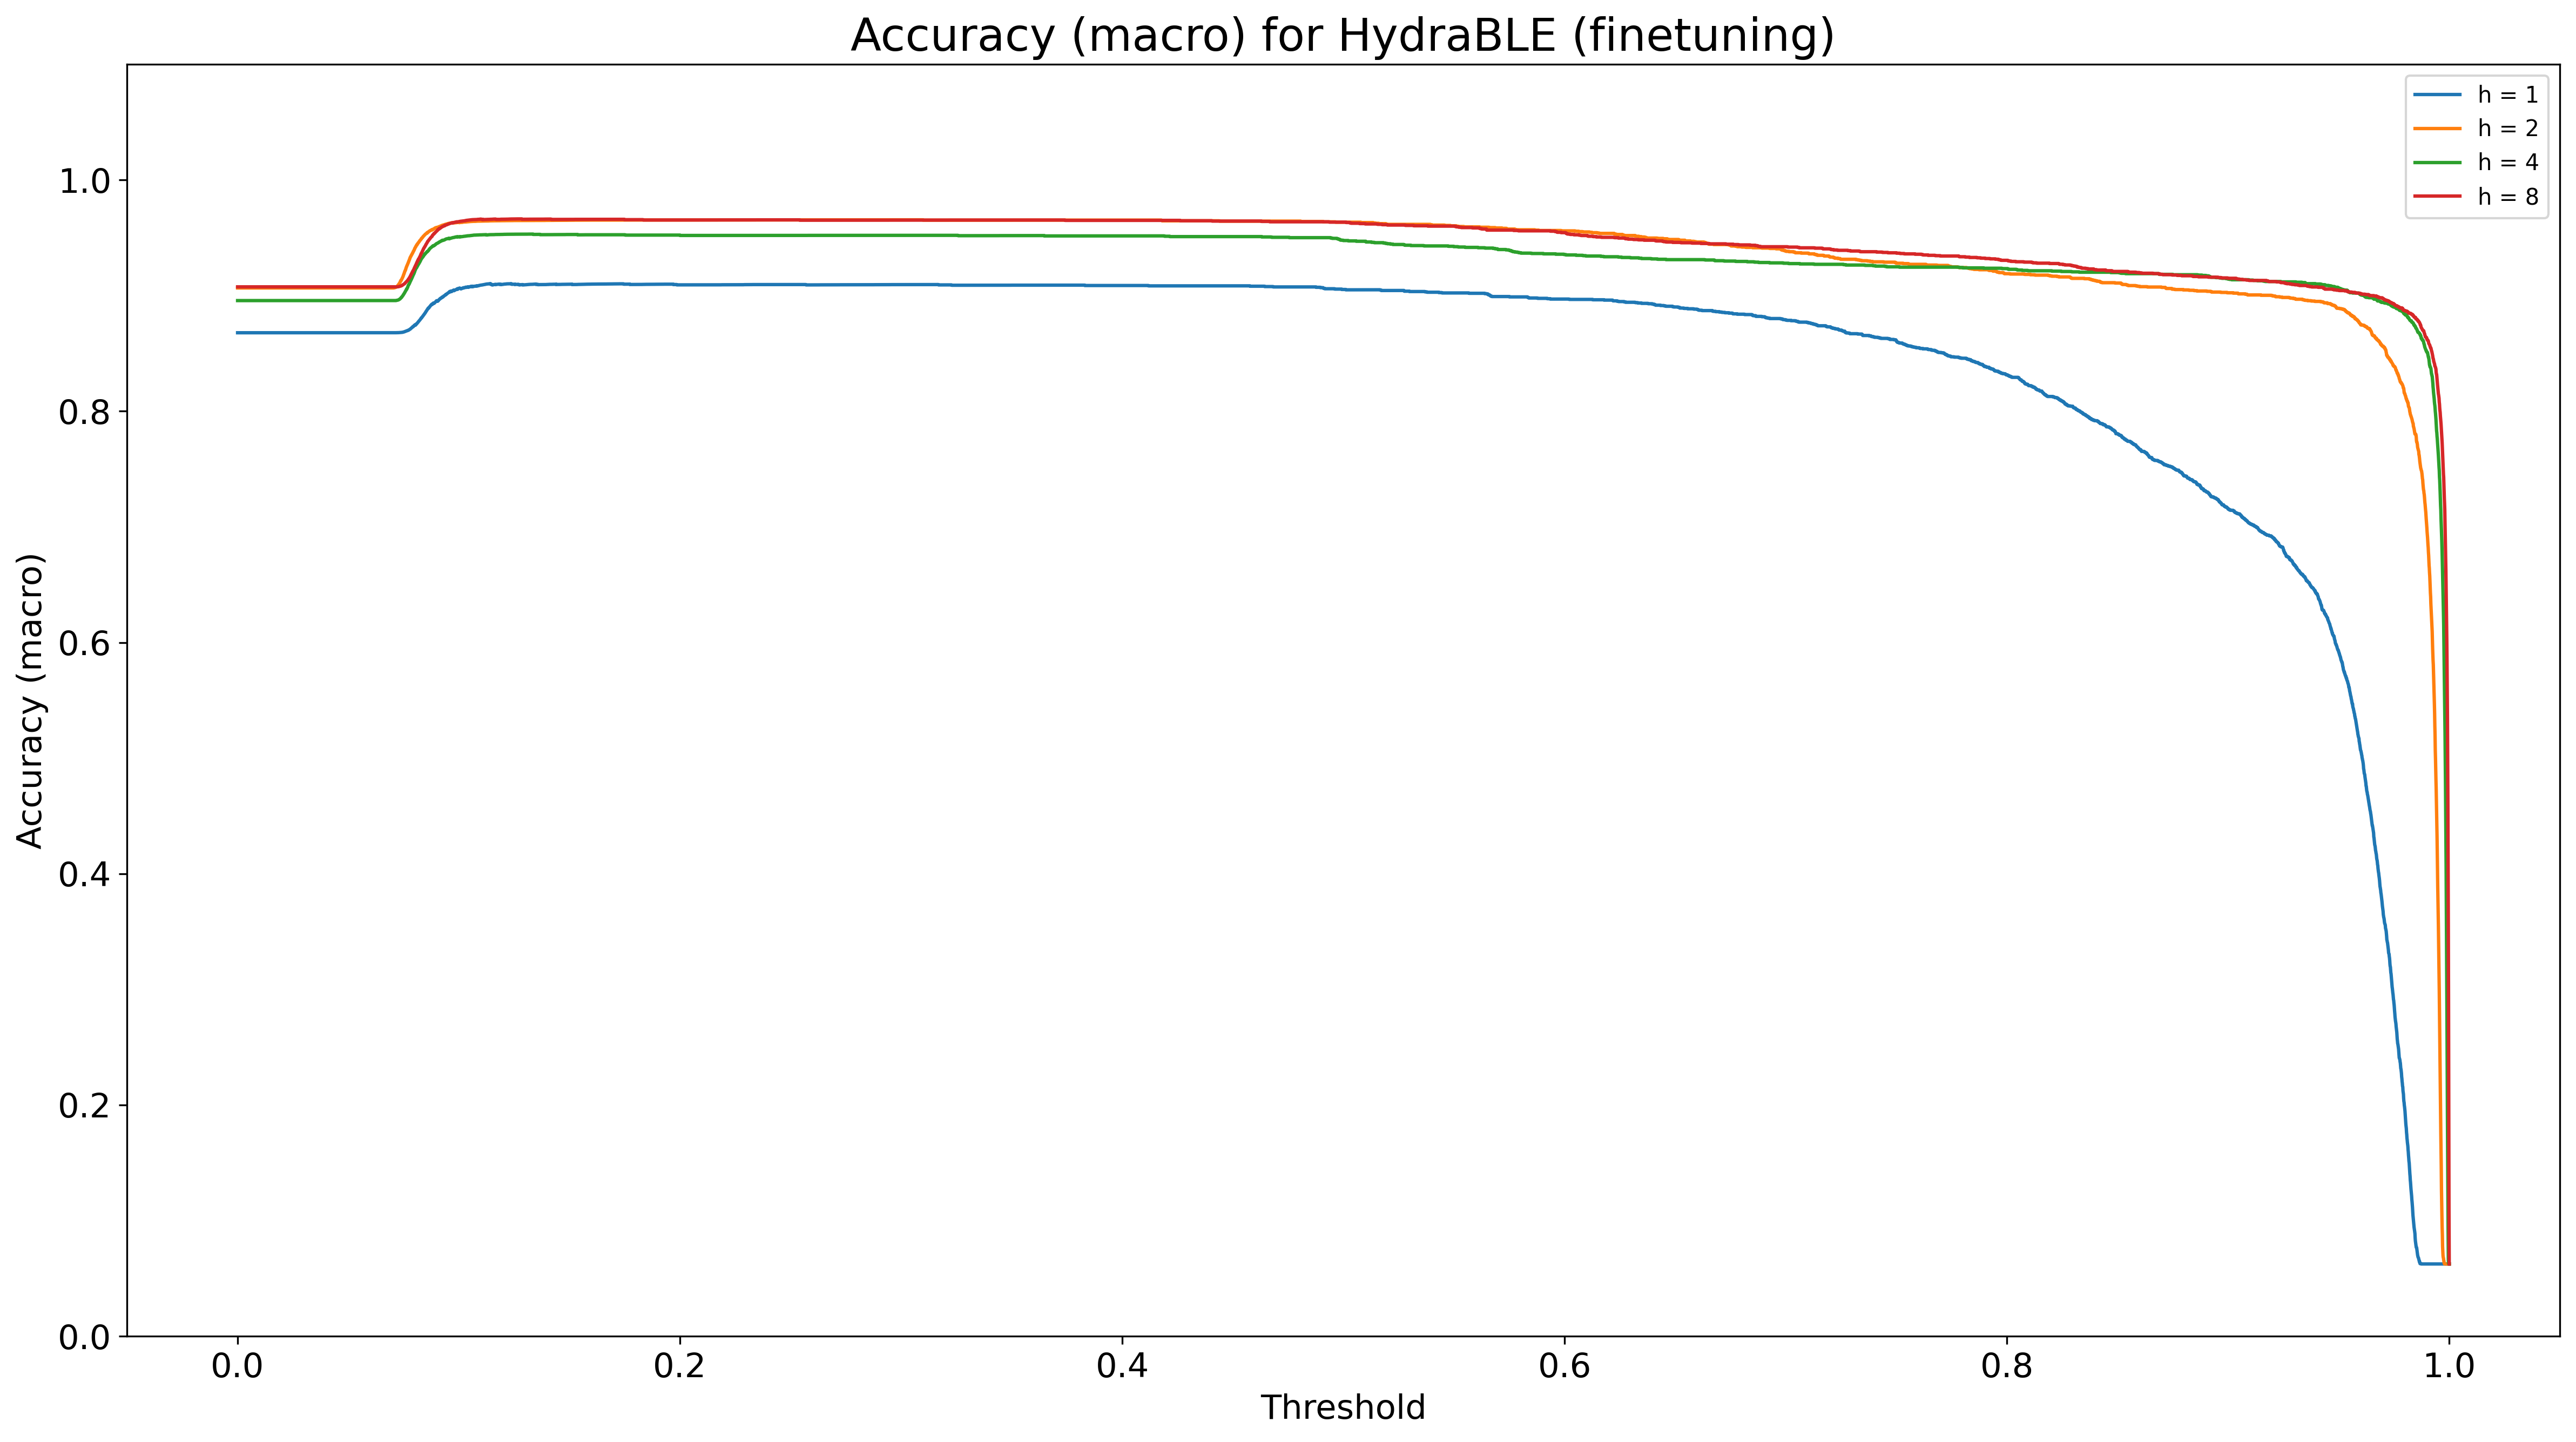

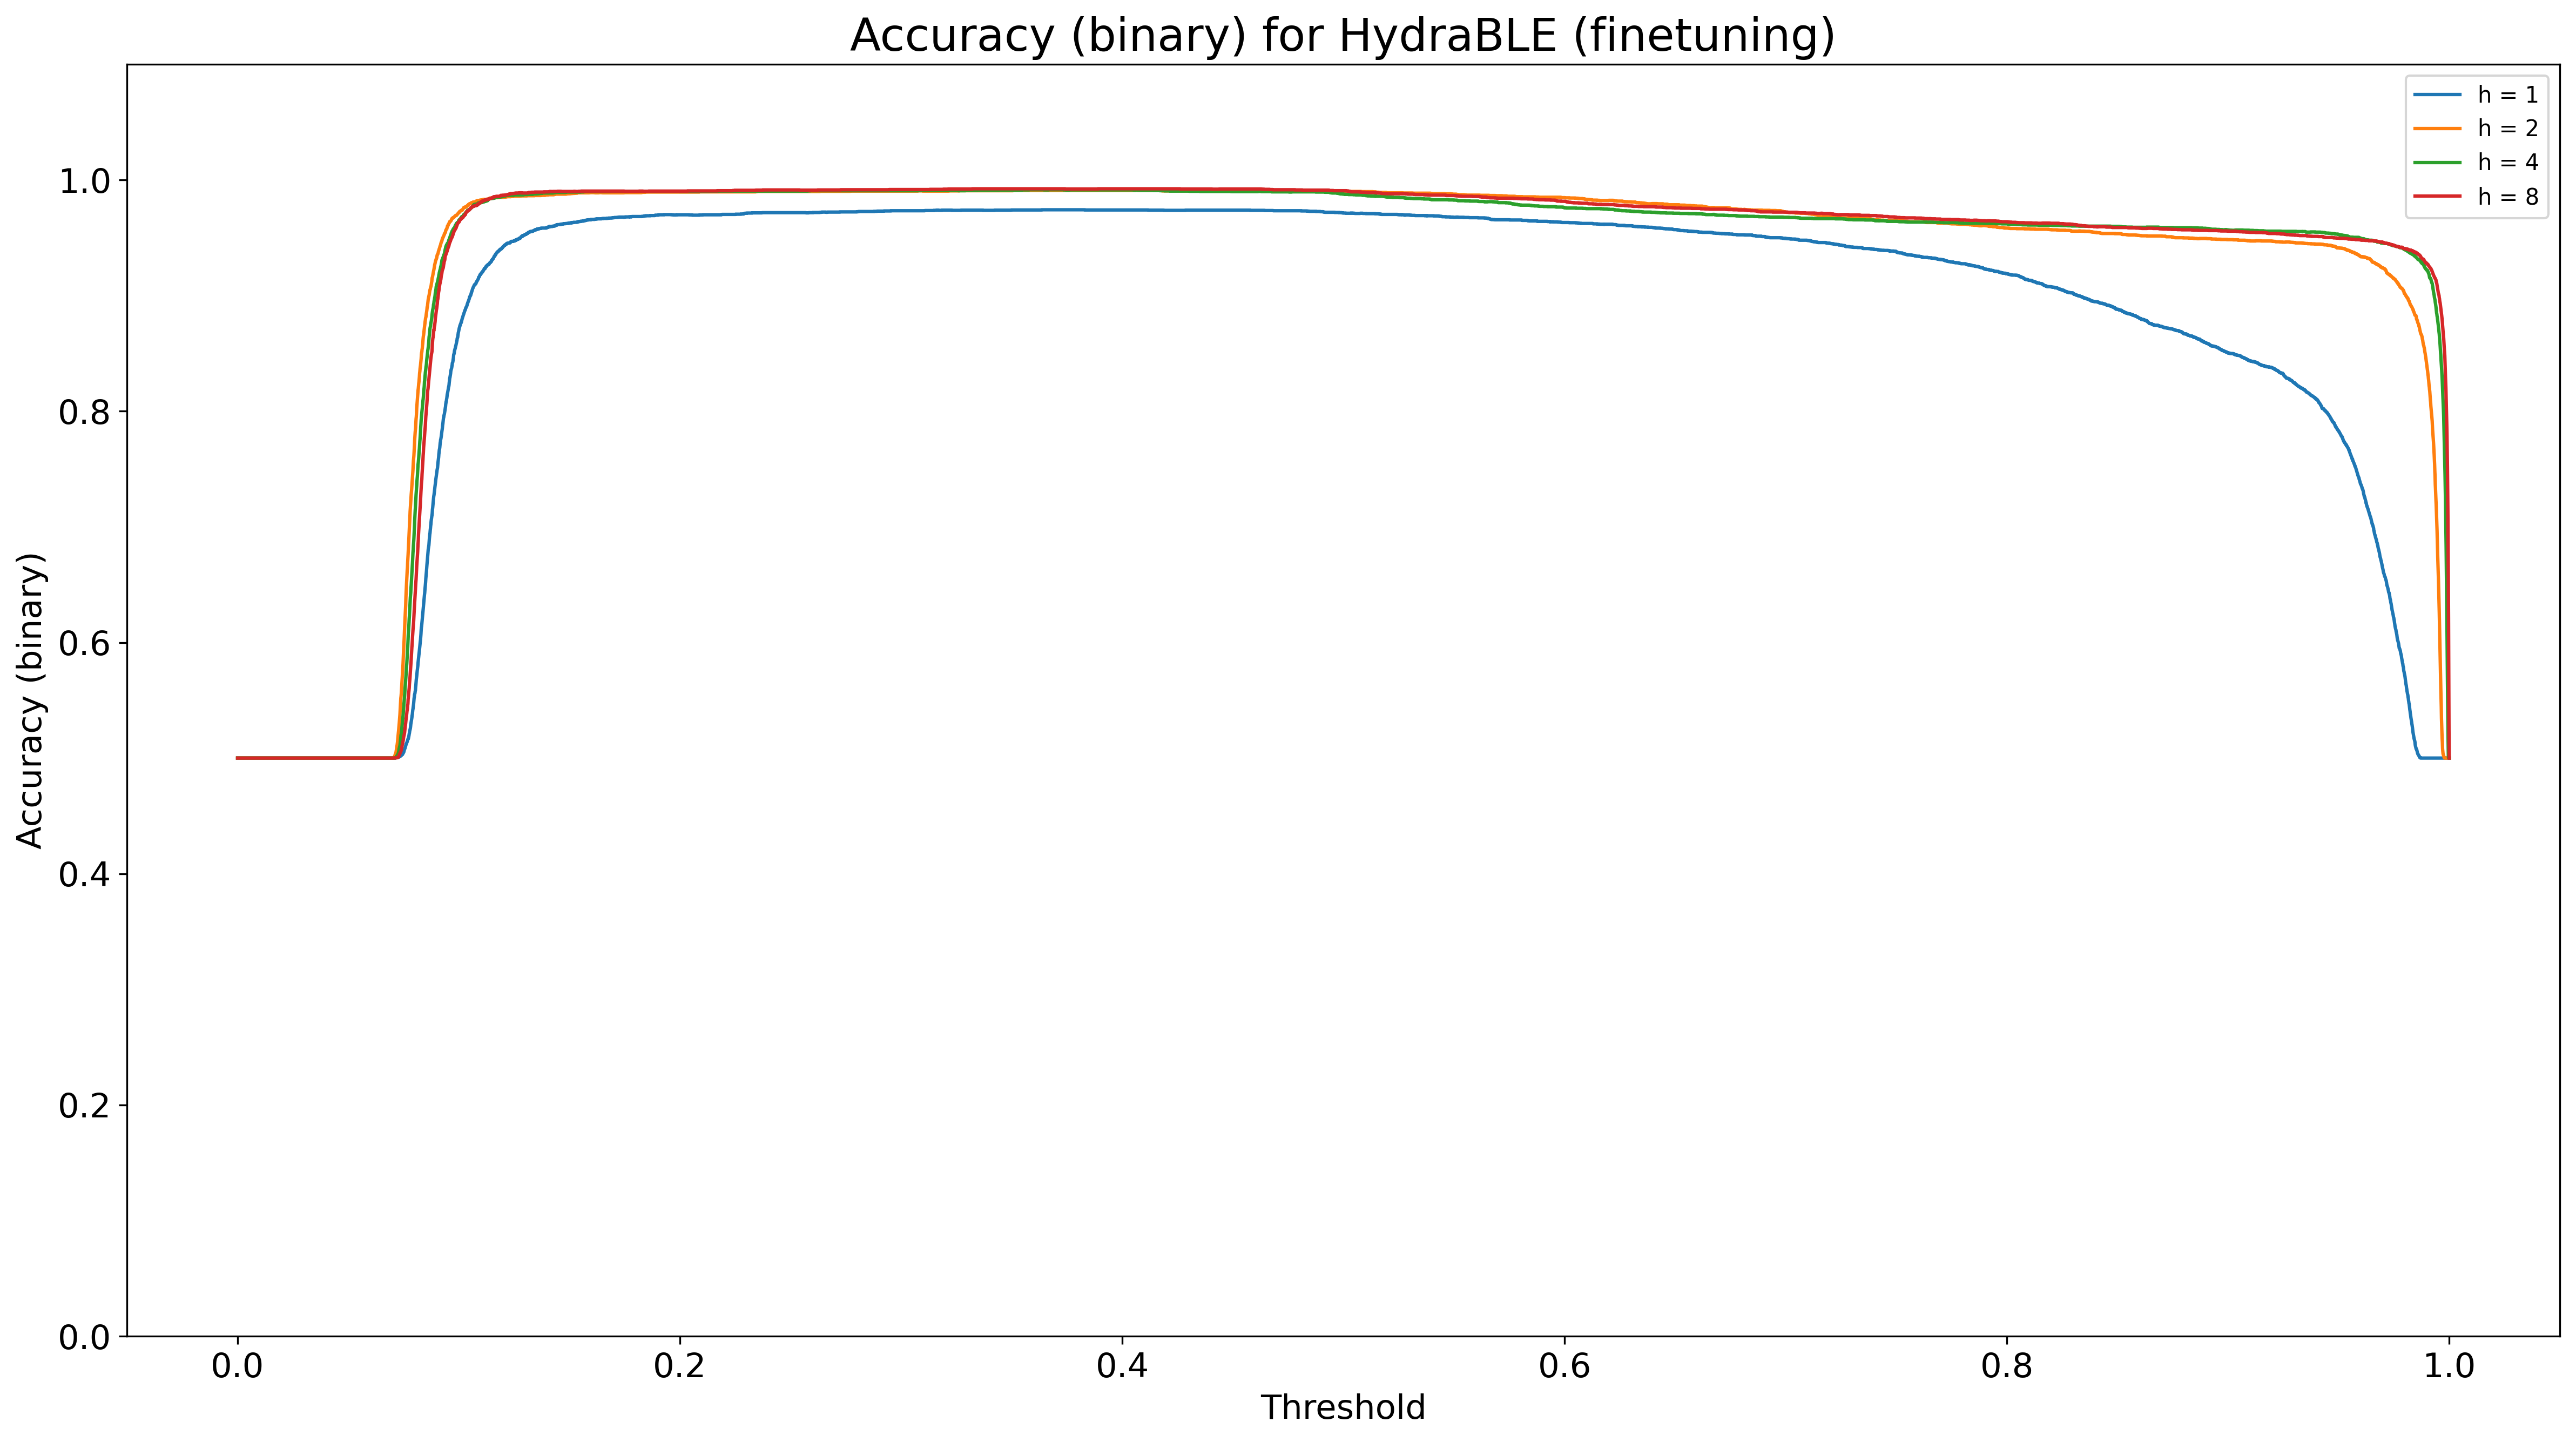

In [8]:
plot_curve(acc_micro_lut, "Accuracy (micro) for HydraBLE (finetuning)", "Accuracy (micro)")
plot_curve(acc_macro_lut, "Accuracy (macro) for HydraBLE (finetuning)", "Accuracy (macro)")
plot_curve(acc_binary_lut,  "Accuracy (binary) for HydraBLE (finetuning)", "Accuracy (binary)")

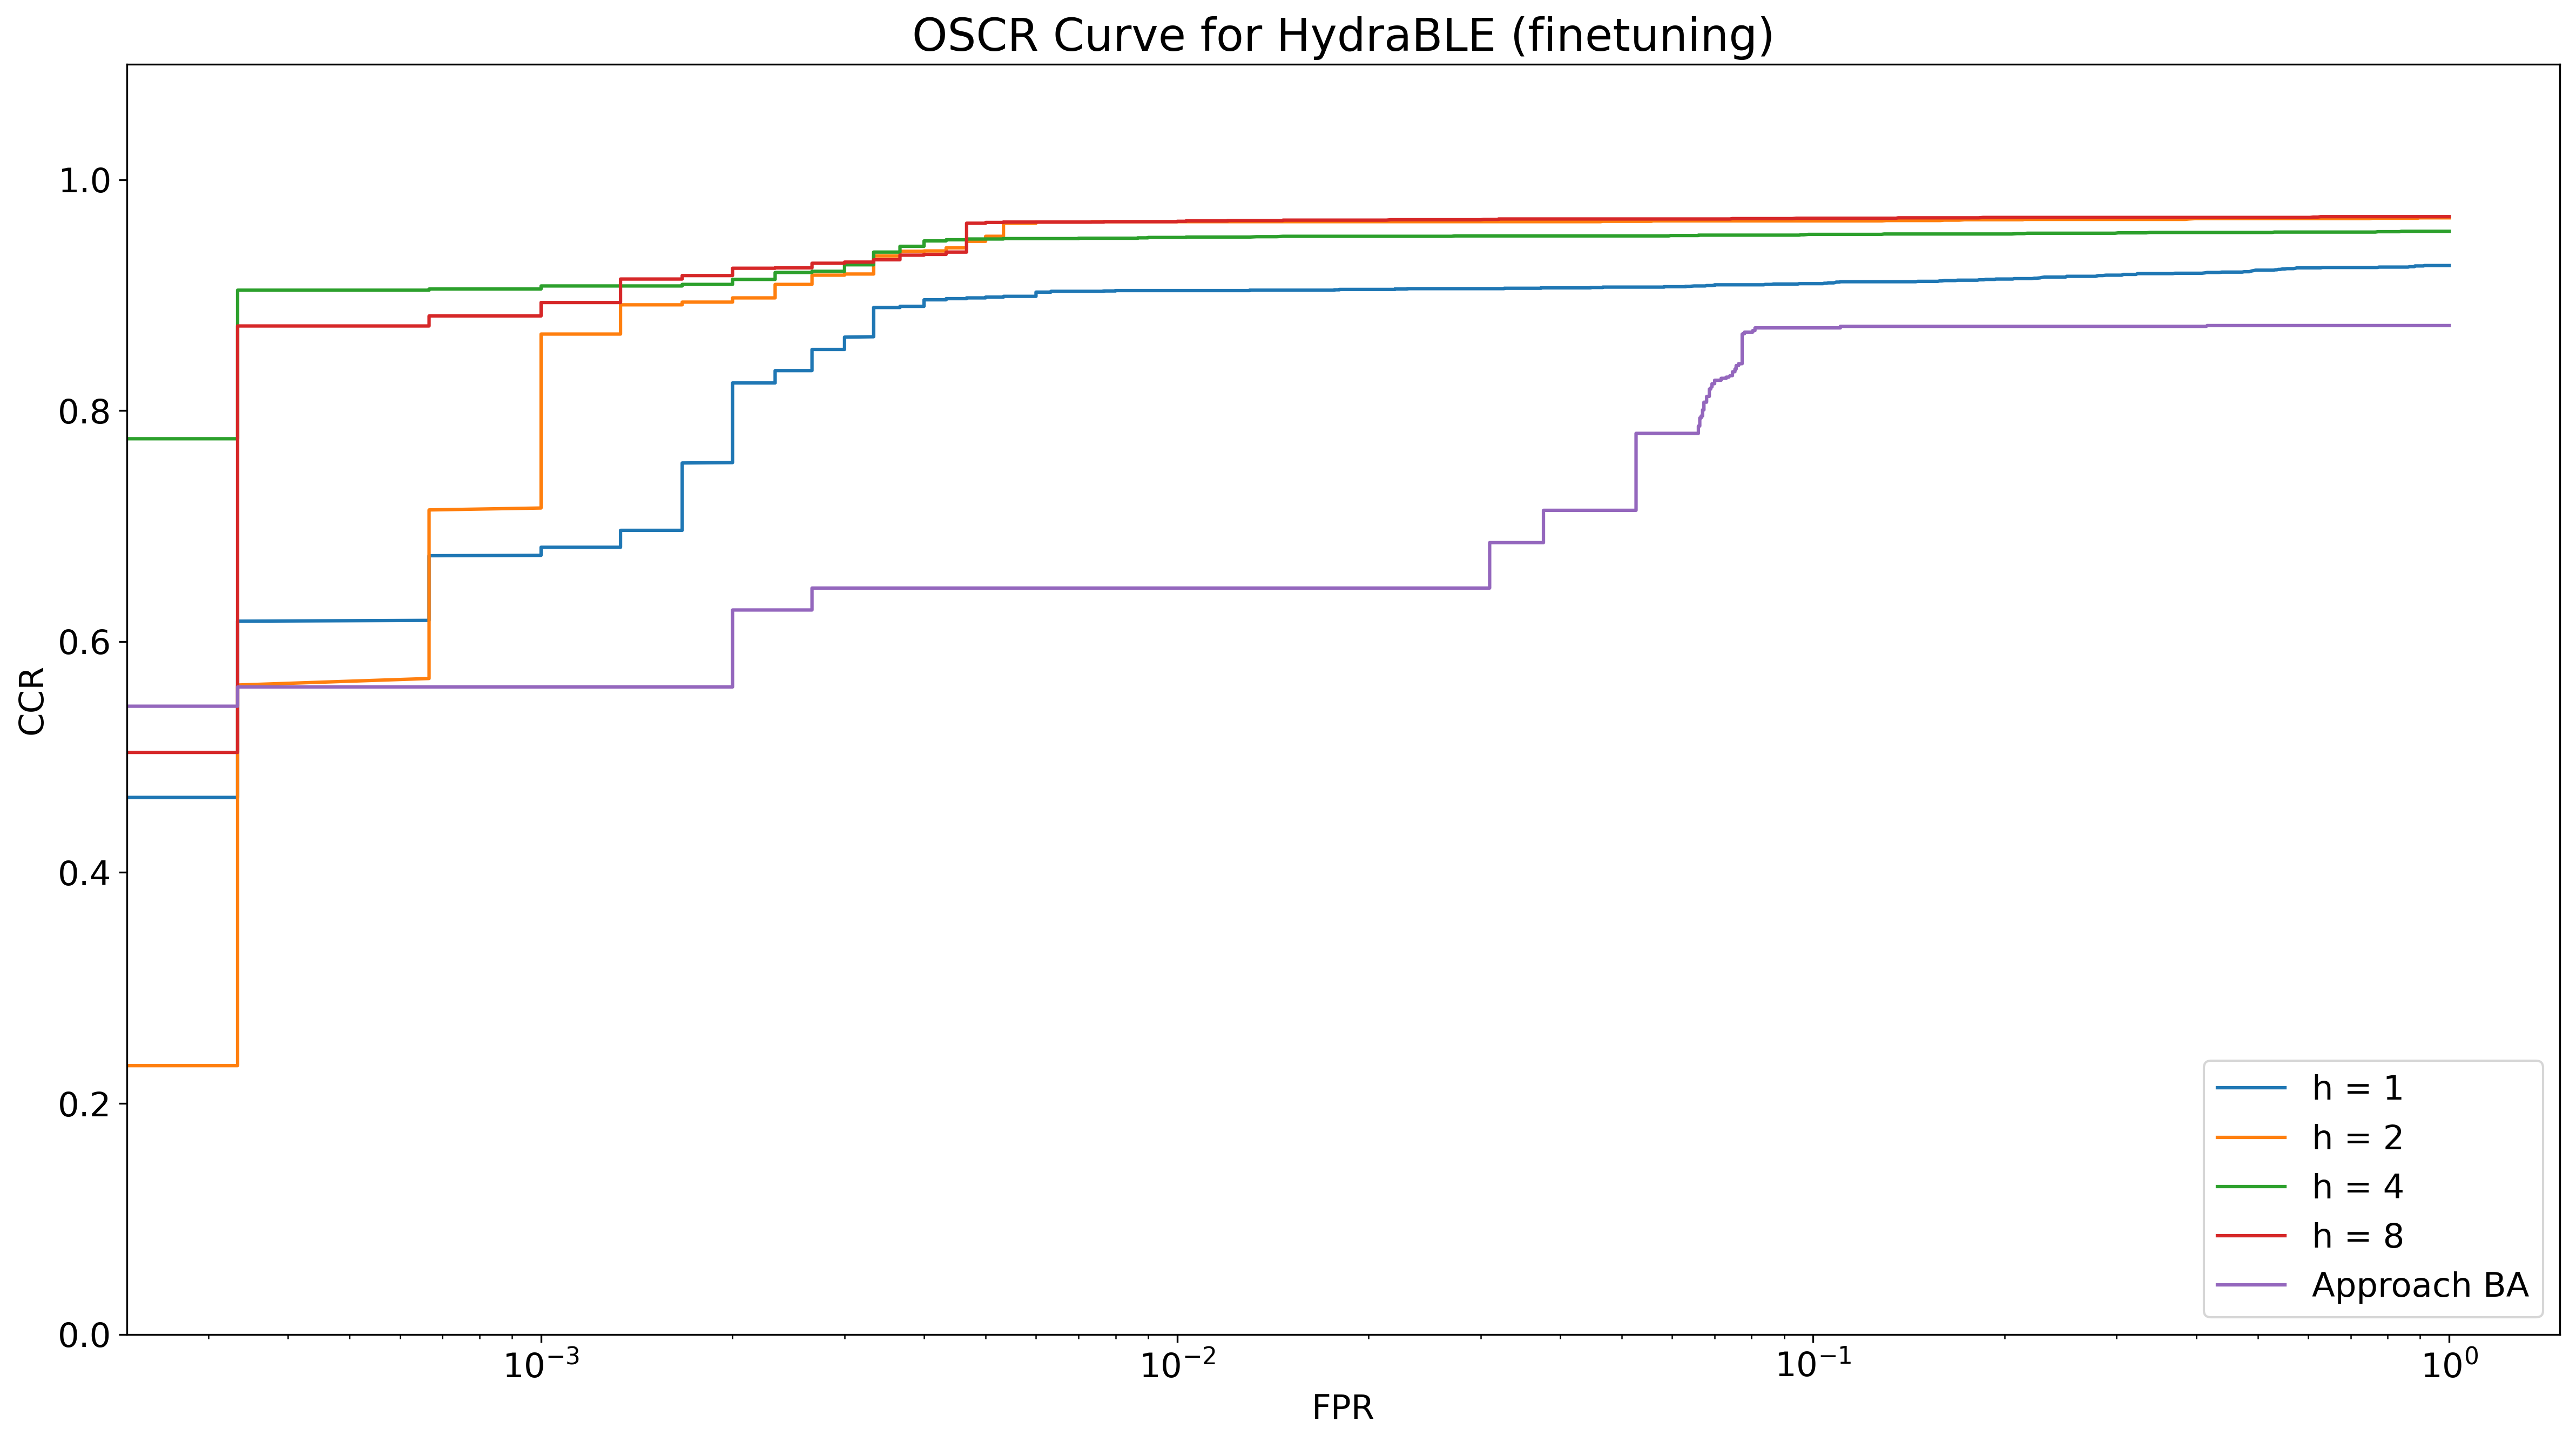

In [13]:
import pickle

picklePathBA = str(Path.cwd()) + r"\out\pickle_objects\modeling_ba" + "\\"

with open(picklePathBA + "ccrs" + '.pickle', 'rb') as f:
    ccrs_ba = pickle.load(f)

with open(picklePathBA +"fprs" + '.pickle', 'rb') as f:
    fprs_ba = pickle.load(f)

plt.figure(figsize=(16, 9), dpi = 300)

for h, values in oscr_lut.items():
    fprs = values[:, 0]
    ccrs = values[:, 1]

    plt.plot(fprs, ccrs, label=f"h = {h}")

plt.plot(fprs_ba, ccrs_ba, label="Approach BA")


plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.xlabel("Threshold", fontsize=FONTSIZE_LABEL)
plt.ylim(0, 1.1)
plt.xscale("log")
plt.ylabel("CCR", fontsize=FONTSIZE_LABEL)
plt.xlabel("FPR", fontsize=FONTSIZE_LABEL)
title = "OSCR Curve for HydraBLE (finetuning)"
plt.title(title, fontsize=FONTSIZE_TITLE)
plt.legend(fontsize=FONTSIZE_LABEL)
plt.tight_layout()
plt.savefig(plotPath + title + ".png", dpi = 300)
plt.show()

In [10]:
metrics = pd.DataFrame(np.array(metric_table).T, columns=("Metric", 1, 2, 4, 8))


In [11]:
metrics.to_csv(tablePath + "Metrics Table HydraBLE (finetuning).csv", index = False)

In [12]:
metrics

,Metric,1,2,4,8
0,Accuracy (micro),0.9483333230018616,0.9783333539962769,0.9711666703224182,0.9788333177566528
1,Accuracy (macro),0.9083749055862427,0.9646250009536743,0.9520624876022339,0.9649791717529297
2,Accuracy (binary),0.9738333225250244,0.9904999732971191,0.9908333420753479,0.9921666383743286
3,CCR at FPR = 1e-1,0.9100000262260437,0.9643333554267883,0.9526666402816772,0.9666666388511658
4,CCR at FPR = 1e-2,0.9039999842643738,0.9636666774749756,0.949999988079071,0.9636666774749756
5,CCR at FPR = 1e-3,0.6746666431427002,0.715666651725769,0.9053333401679993,0.8820000290870667
